<a href="https://colab.research.google.com/github/RishabKr15/Bike-Sharing-Demand-Prediction/blob/main/NETFLIX_MOVIES_AND_TV_SHOWS_CLUSTERING_up.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - NETFLIX MOVIES AND TV SHOWS CLUSTERING



##### **Project Type**    - **Unsupervised**
##### **Contribution**    - **Individual**
##### **Name**            - **Rishabh Kumar**


# **Project Summary -**

This project was all about analyzing Netflix’s catalog of TV shows and movies from 2019 using NLP techniques. The goal was to group similar content into clusters and build a content-based recommendation system to improve user experience and reduce subscriber churn. With over 200 million subscribers, Netflix is the largest online streaming service provider, and it is crucial to continually improve its offerings.

### **Project Approach & Key Steps:**
**🔹 Data Cleaning & Preprocessing** <br>
I started by handling missing values and breaking down nested attributes like director, cast, listed_in, and country. Cleaning and organizing this data properly was key to making meaningful observations later.

**🔹 Content Categorization**<br>
To make the recommendations more relevant, I grouped ratings into broader categories like Adult, Children’s, Family-Friendly, and Not Rated. This helped in filtering content based on audience type.

**🔹 Exploratory Data Analysis (EDA)** <br>
Exploratory data analysis (EDA) was conducted to gain valuable insights into various attributes within the dataset. This process involved examining patterns, distributions, and relationships in the data, providing a deeper understanding of the content available on Netflix..

**🔹 NLP-Based Feature Engineering** <br>
To create clusters, i employed NLP techniques by tokenizing, preprocessing, and vectorizing attributes such as director, cast, country, genre, rating, and description using the TFIDF vectorizer. This allowed us to quantify textual data and identify similarities among TV shows and movies.

**🔹 Dimensionality Reduction & Clustering** <br>
To improve efficiency, I applied Principal Component Analysis (PCA) to reduce dimensionality before clustering. Then, I experimented with K-Means and Agglomerative Hierarchical Clustering to find the optimal way to group similar content.  The optimal number of clusters was determined using evaluation metrics such as the Elbow method, Silhouette score, and dendrogram analysis.

**🔹 Building the Recommendation System** <br>
Finally, I built a content-based recommender system using cosine similarity. This system analyzes a user’s viewing history and suggests similar content, making it easier for users to discover shows and movies they’d enjoy.By delivering tailored suggestions, the recommender system aimed to improve user satisfaction and reduce churn.

**Final Thoughts:**<br>
This project was a great way to apply NLP, clustering techniques, and recommendation algorithms in a real-world scenario. By grouping content effectively and providing personalized recommendations, the system could help increase user engagement and reduce churn for a platform like Netflix.


# **GitHub Link -**

https://github.com/RishabKr15/Netflix-Movies-and-TV-Shows-Clustering

# **Problem Statement**


**This dataset consists of tv shows and movies available on Netflix as of 2019. The dataset is collected from Flixable which is a third-party Netflix search engine.**

**In 2018, they released an interesting report which shows that the number of TV shows on Netflix has nearly tripled since 2010. The streaming service’s number of movies has decreased by more than 2,000 titles since 2010, while its number of TV shows has nearly tripled. It will be interesting to explore what all other insights can be obtained from the same dataset.**

**We will be clustering similar content by matching text-based features.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
# Data Maipulation Libraries
import numpy as np
import pandas as pd
import datetime as dt

# Data Visualisation Libraray
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from wordcloud import WordCloud, STOPWORDS
import seaborn as sns
%matplotlib inline

# Importing libraries for hypothesis testing
from scipy.stats import uniform
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import t
from scipy.stats import f
from scipy.stats import ttest_ind
import scipy.stats as stats

# libraries used to process textual data
import string
string.punctuation
import nltk
nltk.download('punkt')
from nltk.corpus import stopwords
nltk.download('stopwords')
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import word_tokenize
from nltk.tokenize import TweetTokenizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# libraries used to implement clusters
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram

# Library of warnings would assist in ignoring warnings issued
import warnings;warnings.filterwarnings('ignore')
import warnings;warnings.simplefilter('ignore')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### Dataset Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AlmaBetter/NETFLIX MOVIES AND TV SHOWS CLUSTERING/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(7787, 12)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


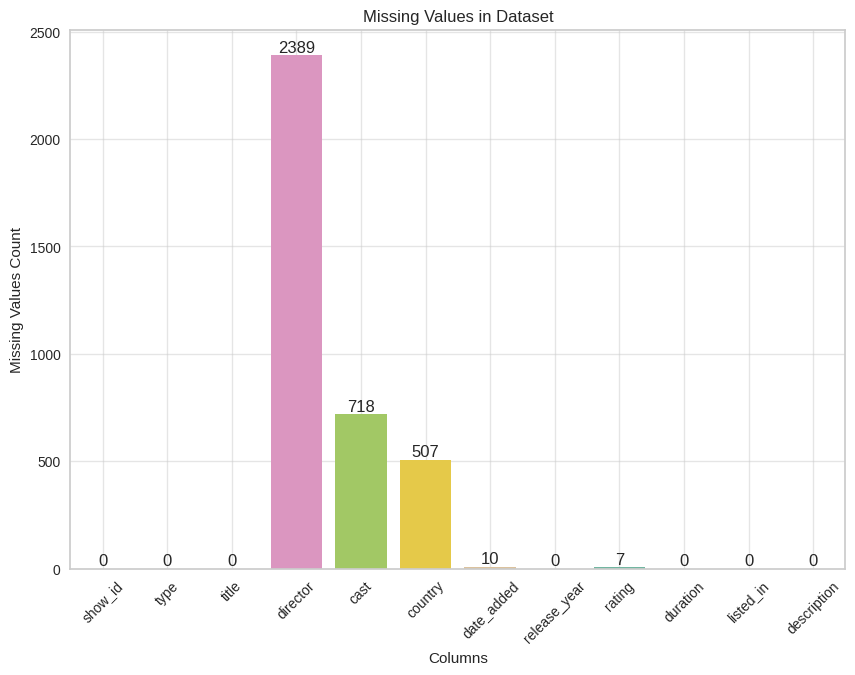

In [ ]:
# Visualizing the missing values
plt.figure(figsize=(10,7))
ax=sns.barplot(x=df.columns,y=df.isna().sum(),palette='Set2')
for label in ax.containers:
    ax.bar_label(label)
plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.xlabel("Columns")
plt.ylabel("Missing Values Count")
plt.title("Missing Values in Dataset")
plt.show()

### What did you know about your dataset?

* We have a dataset that contains Movies/TV shows in Netflix until 2019.
* The dataset has 7787 entries and 12 columns. Out of the 12 columns, 11 are of 'object' datatype and 1 is of 'numeric' datatype.
* There are no duplicate values in the dataset.
* There are five columns containing missing values.
* There are total 3631 missing values present in the dataset.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


### Variables Description

1. *show_id* : Unique ID for every Movie/TV show
2. *type* : A movie or a TV show
3. *title* : Title of the Movie/TV show
4. *director* : Director of the Movie/TV show
5. *cast* : Actors in the movie
6. *country* : Country of produciton
7. *date_added* : Date it was added on Netflix
8. *release_year* : Actual release year of the Movie/TV show
9. *rating* : Movie/TV show rating
10. *duration* : duration in minutes/number of seasons
11. *listed_in* : Genre
12. *Description* : The description summary


### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()

,0
show_id,7787
type,2
title,7787
director,4049
cast,6831
country,681
date_added,1565
release_year,73
rating,14
duration,216


## 3. ***Data Wrangling***

### Data Wrangling Code

### 1. Handling null values

In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [ ]:
df[['director','cast']]=df[['director','cast']].fillna('Unknown')
df['country']=df['country'].fillna(df['country'].mode()[0])
df.dropna(axis=0, inplace=True)

In [ ]:
df.shape

(7770, 12)

In [ ]:
df.duplicated().sum()

np.int64(0)

* To handle null values in the 'director' and 'cast' columns, we can replace them with the value 'Unknown'. This ensures that missing information in these columns is still captured in the dataset.
* For the 'country' column, we can fill the null values with the country that appears most frequently in the dataset, using the mode.

### 2. Handling nested columns i.e 'director', 'cast', 'listed_in' and 'country'

In [ ]:
# Let's create a copy of dataframe and unnest the original one
df_new = df.copy()

In [ ]:
#Unnesting 'Directors' column
dir=df['director'].apply(lambda x: str(x).split(',')).tolist()
df1=pd.DataFrame(dir,index=df['title'])
df1=df1.stack()
df1=pd.DataFrame(df1.reset_index())
df1.rename(columns={0:'Directors'},inplace=True)
df1 = df1.drop(['level_1'],axis=1)
df1.sample(10)

,title,Directors
6674,The Bomb,Kevin Ford
7066,The Intouchables,Éric Toledano
5290,Point Blank,Joe Lynch
1209,Buddi,Unknown
1239,BuyBust,Erik Matti
975,Bigflo & Oli: Hip Hop Frenzy,Jérémie Levypon
4702,My Secret Romance,Unknown
688,Away,Unknown
5732,Run On,Unknown
4437,Mirzya,Rakeysh Omprakash Mehra


In [ ]:
df1.shape

(8487, 2)

In [ ]:
# Unnesting 'cast' column
cast=df['cast'].apply(lambda x: str(x).split(',')).tolist()
df2=pd.DataFrame(cast,index=df['title'])
df2=df2.stack()
df2=pd.DataFrame(df2.reset_index())
df2.rename(columns={0:'Actors'},inplace=True)
df2 = df2.drop(['level_1'],axis=1)
df2.sample(10)

,title,Actors
24595,Klaus,Will Sasso
39336,SETHUM AAYIRAM PON,Rathaa Krishnan P.
8752,Caida del Cielo,Sebastián Wainraich
12224,Death Can Wait,Jairo Ordóñez
49651,The Secret,Tyas Mirasih
26484,Loaded,Samuel Anderson
919,5 Flights Up,Claire van der Boom
43032,Tarzan,Rosie O'Donnell
4296,Arthdal Chronicles,Song Joong-ki
14056,Earth to Echo,Reese Hartwig


In [ ]:
df2.shape

(56563, 2)

In [ ]:
# Unnesting 'listed_in' column
lst=df['listed_in'].apply(lambda x: str(x).split(', ')).tolist()
df3 = pd.DataFrame(lst, index = df['title'])
df3 = df3.stack()
df3 = pd.DataFrame(df3.reset_index())
df3.rename(columns={0:'Genre'},inplace=True)
df3 = df3.drop(['level_1'],axis=1)
df3.sample(10)

,title,Genre
8598,Mantostaan,Dramas
1855,Berserk: The Golden Age Arc II - The Battle fo...,International Movies
11724,Samantaral,International Movies
3880,Disappearance,TV Mysteries
8736,Mater,International Movies
16,187,Dramas
2493,Bumping Mics with Jeff Ross & Dave Attell,Stand-Up Comedy & Talk Shows
9899,Nothing to Hide,Dramas
12419,Smoke & Mirrors,Dramas
226,3 Türken & ein Baby,International Movies


In [ ]:
df3.shape

(17042, 2)

In [ ]:
# Unnesting 'country' column
country=df['country'].apply(lambda x: str(x).split(', ')).tolist()
df4 = pd.DataFrame(country, index = df['title'])
df4 = df4.stack()
df4 = pd.DataFrame(df4.reset_index())
df4.rename(columns={0:'Country'},inplace=True)
df4 = df4.drop(['level_1'],axis=1)
df4.sample(10)

,title,Country
3720,Ip Man,China
6892,Son of a Gun,Canada
2697,For the Birds,United States
3163,Hank: Five Years from the Brink,United States
2396,El testigo,United Kingdom
1013,Bennett's War,United States
1538,Chal Bhaag,India
1493,Carriers,United States
5245,My Way,Italy
3129,Ha Unlimited,United States


In [ ]:
df4.shape

(9553, 2)

#### **Merging**:

In [ ]:
## Merging all the unnested dataframes
# Merging director and cast
df5 = df2.merge(df1,on=['title'],how='inner')

# Merging listed_in with merged of (director and cast)
df6 = df5.merge(df3,on=['title'],how='inner')

# Merging country with merged of [listed_in with merged of (director and cast)]
df7 = df6.merge(df4,on=['title'],how='inner')

# Head of final merged dataframe
df7.head()

,title,Actors,Directors,Genre,Country
0,3%,João Miguel,Unknown,International TV Shows,Brazil
1,3%,João Miguel,Unknown,TV Dramas,Brazil
2,3%,João Miguel,Unknown,TV Sci-Fi & Fantasy,Brazil
3,3%,Bianca Comparato,Unknown,International TV Shows,Brazil
4,3%,Bianca Comparato,Unknown,TV Dramas,Brazil


In [ ]:
# Final DataFrame:
df=df7.merge(df[['type', 'title', 'date_added', 'release_year', 'rating', 'duration','description']],on=['title'],how='left')
df.head()

,title,Actors,Directors,Genre,Country,type,date_added,release_year,rating,duration,description
0,3%,João Miguel,Unknown,International TV Shows,Brazil,TV Show,"August 14, 2020",2020,TV-MA,4 Seasons,In a future where the elite inhabit an island ...
1,3%,João Miguel,Unknown,TV Dramas,Brazil,TV Show,"August 14, 2020",2020,TV-MA,4 Seasons,In a future where the elite inhabit an island ...
2,3%,João Miguel,Unknown,TV Sci-Fi & Fantasy,Brazil,TV Show,"August 14, 2020",2020,TV-MA,4 Seasons,In a future where the elite inhabit an island ...
3,3%,Bianca Comparato,Unknown,International TV Shows,Brazil,TV Show,"August 14, 2020",2020,TV-MA,4 Seasons,In a future where the elite inhabit an island ...
4,3%,Bianca Comparato,Unknown,TV Dramas,Brazil,TV Show,"August 14, 2020",2020,TV-MA,4 Seasons,In a future where the elite inhabit an island ...


In [ ]:
df.shape

(175807, 11)

### 3. Changing datatype

In [ ]:
# 'date_added' column:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
# Extracting  day, month and year from date_added column
df["day_added"]= df["date_added"].dt.day
df["month_added"]= df["date_added"].dt.month
df["year_added"]= df["date_added"].dt.year

# Dropping date_added
df.drop('date_added', axis=1, inplace=True)

# removing 'min' and 'Seasons' from the end in 'duration' column:
df['duration']= df['duration'].apply(lambda x: int(x.split()[0]))


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175807 entries, 0 to 175806
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   title         175807 non-null  object
 1   Actors        175807 non-null  object
 2   Directors     175807 non-null  object
 3   Genre         175807 non-null  object
 4   Country       175807 non-null  object
 5   type          175807 non-null  object
 6   release_year  175807 non-null  int64 
 7   rating        175807 non-null  object
 8   duration      175807 non-null  int64 
 9   description   175807 non-null  object
 10  day_added     175807 non-null  int32 
 11  month_added   175807 non-null  int32 
 12  year_added    175807 non-null  int32 
dtypes: int32(3), int64(2), object(8)
memory usage: 15.4+ MB


### 4. Binning of Rating variable

In rating columns we have different categories these are content rating classifications that are commonly used in the United States and other countries to indicate the appropriateness of media content for different age groups. Let's understand each of them and binnig them accordingly:

**TV-MA**: This rating is used for mature audiences only, and it may contain strong language, violence, nudity, and sexual content.

**R**: This rating is used for movies that are intended for audiences 17 and older. It may contain graphic violence, strong language, drug use, and sexual content.

**PG-13**: This rating is used for movies that may not be suitable for children under 13. It may contain violence, mild to moderate language, and suggestive content.

**TV-14**: This rating is used for TV shows that may not be suitable for children under 14. It may contain violence, strong language, sexual situations, and suggestive dialogue.

**TV-PG**: This rating is used for TV shows that may not be suitable for children under 8. It may contain mild violence, language, and suggestive content.

**NR**: This stands for "Not Rated." It means that the content has not been rated by a rating board, and it may contain material that is not suitable for all audiences.

**TV-G**: This rating is used for TV shows that are suitable for all ages. It may contain some mild violence, language, and suggestive content.

**TV-Y**: This rating is used for children's TV shows that are suitable for all ages. It is intended to be appropriate for preschool children.

**TV-Y7**: This rating is used for children's TV shows that may not be suitable for children under 7. It may contain mild violence and scary content.

**PG**: This rating is used for movies that may not be suitable for children under 10. It may contain mild language, some violence, and some suggestive content.

**G**: This rating is used for movies that are suitable for general audiences. It may contain some mild language and some violence.

**NC-17**: This rating is used for movies that are intended for adults only. It may contain explicit sexual content, violence, and language.

**TV-Y7-FV**: This rating is used for children's TV shows that may not be suitable for children under 7. It may contain fantasy violence.

**UR**: This stands for "Unrated." It means that the content has not been rated by a rating board, and it may contain material that is not suitable for all audiences.

Let's not complicate it and create bins as following:
* **Adult Content**: TV-MA, NC-17, R
* **Children Content**:  TV-PG, PG, TV-G, G
* **Teen Content**: PG-13, TV-14
* **Family-friendly Content**: TV-Y, TV-Y7, TV-Y7-FV
* **Not Rated**: NR, UR

In [ ]:
# Binning the values in the rating column
rating_map = {'TV-MA':'Adult Content',
              'R':'Adult Content',
              'PG-13':'Teen Content',
              'TV-14':'Teen Content',
              'TV-PG':'Children Content',
              'NR':'Not Rated',
              'TV-G':'Children Content',
              'TV-Y':'Family-friendly Content',
              'TV-Y7':'Family-friendly Content',
              'PG':'Children Content',
              'G':'Children Content',
              'NC-17':'Adult Content',
              'TV-Y7-FV':'Family-friendly Content',
              'UR':'Not Rated'}

df['rating'].replace(rating_map, inplace = True)
df['rating'].unique()

array(['Adult Content', 'Teen Content', 'Children Content', 'Not Rated',
       'Family-friendly Content'], dtype=object)

In [ ]:
df.sample(3)

,title,Actors,Directors,Genre,Country,type,release_year,rating,duration,description,day_added,month_added,year_added
51405,Funan,Emilie Marié,Denis Do,Dramas,"Cambodia,",Movie,2018,Teen Content,87,Separated from their young son during the brut...,18,7,2020
97423,Naruto Shippuden : Blood Prison,Kosei Hirota,Masahiko Murata,Anime Features,Japan,Movie,2011,Teen Content,102,Mistakenly accused of an attack on the Fourth ...,1,9,2017
89129,Mexico Diseña,Unknown,Unknown,Reality TV,United States,TV Show,2016,Children Content,1,Young fashion designers vie for the chance to ...,1,2,2017


### 5. Separating Movies and TV Shows

In [ ]:
# Spearating the dataframes for further analysis
df_movies= df[df['type']== 'Movie']
df_tvshows= df[df['type']== 'TV Show']

# Printing the shape
print(df_movies.shape, df_tvshows.shape)

(126079, 13) (49728, 13)


### What all manipulations have you done and insights you found?

We have divided data wrangling into five different sections:
1. In this section we have imputed/drop the null values of:
  * Imputed 'director' and 'cast' with 'Unknown'.
  * Imputed 'country' with Mode.
  * Drop null values of 'date_added' and 'rating' .
2. We have unnested values from following features:
    * 'director'
    * 'cast'
    * 'listed_in'
    * 'country'

    We have unnested the values and stored in different dataframes and then  merged all the dataframe with the original one using left join in order to get the isolated values of each of the feature.
3.* We have changed  the data type of  following features:
    * 'duration' into integer (Removing min and seasons from the values).
    * 'date_added' to datetime (Into the required format).
  * We have also extracted the following features:
    * 'date' from 'date_added'.
    * 'month' from 'date_added'.
    * 'year' from 'date_added'.
4. We have seen that the 'rating' column contains various coded categories, so  we have decided to create 5 bins and distribute the values accordingly:
    * **Adult**: TV-MA, NC-17
    * **Restricted**: R, UR
    * **Teen**: PG-13, TV-14
    * **All Ages**: TV-G, TV-Y, TV-Y7, TV-Y7-FV, PG, G, TV-PG
    * **Not Rated**: NR
5. Lastly we have splitted the dataframe into two df one is 'df_movies' that contains only Movies and the other is 'df_tvshows' that contains only TV Shows for our further analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

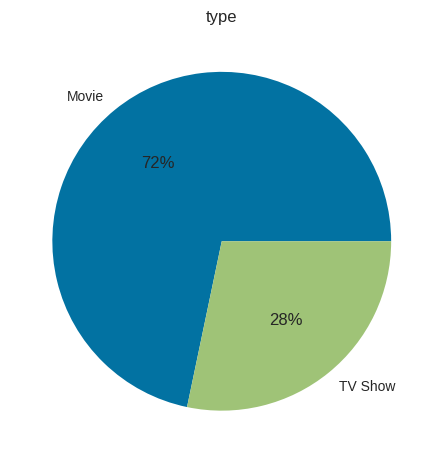

In [ ]:
# Chart - 1 visualization code
# Plotting a piechart for categorical variable- 'type'

plt.pie(df['type'].value_counts(),labels = df['type'].value_counts().keys().tolist(),autopct='%.0f%%')
plt.title('type')
plt.show()

##### 1. Why did you pick the specific chart?

Pie charts are one of the best ways for univariate analysis of categorical data.

##### 2. What is/are the insight(s) found from the chart?

In our dataset, we have 72% of them as movies, the rest 28% is TV shows.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insight that there are more movies on Netflix than TV shows is unlikely to have a significant positive or negative business impact on its own. However, this information could be used in conjunction with other insights and data to inform business decisions.

For example, if Netflix notices that TV shows are more popular with its subscribers than movies, it may decide to focus more on acquiring TV show content. Alternatively, if it sees that its original movie productions are gaining popularity, it may decide to invest more in that area.

#### Chart - 2

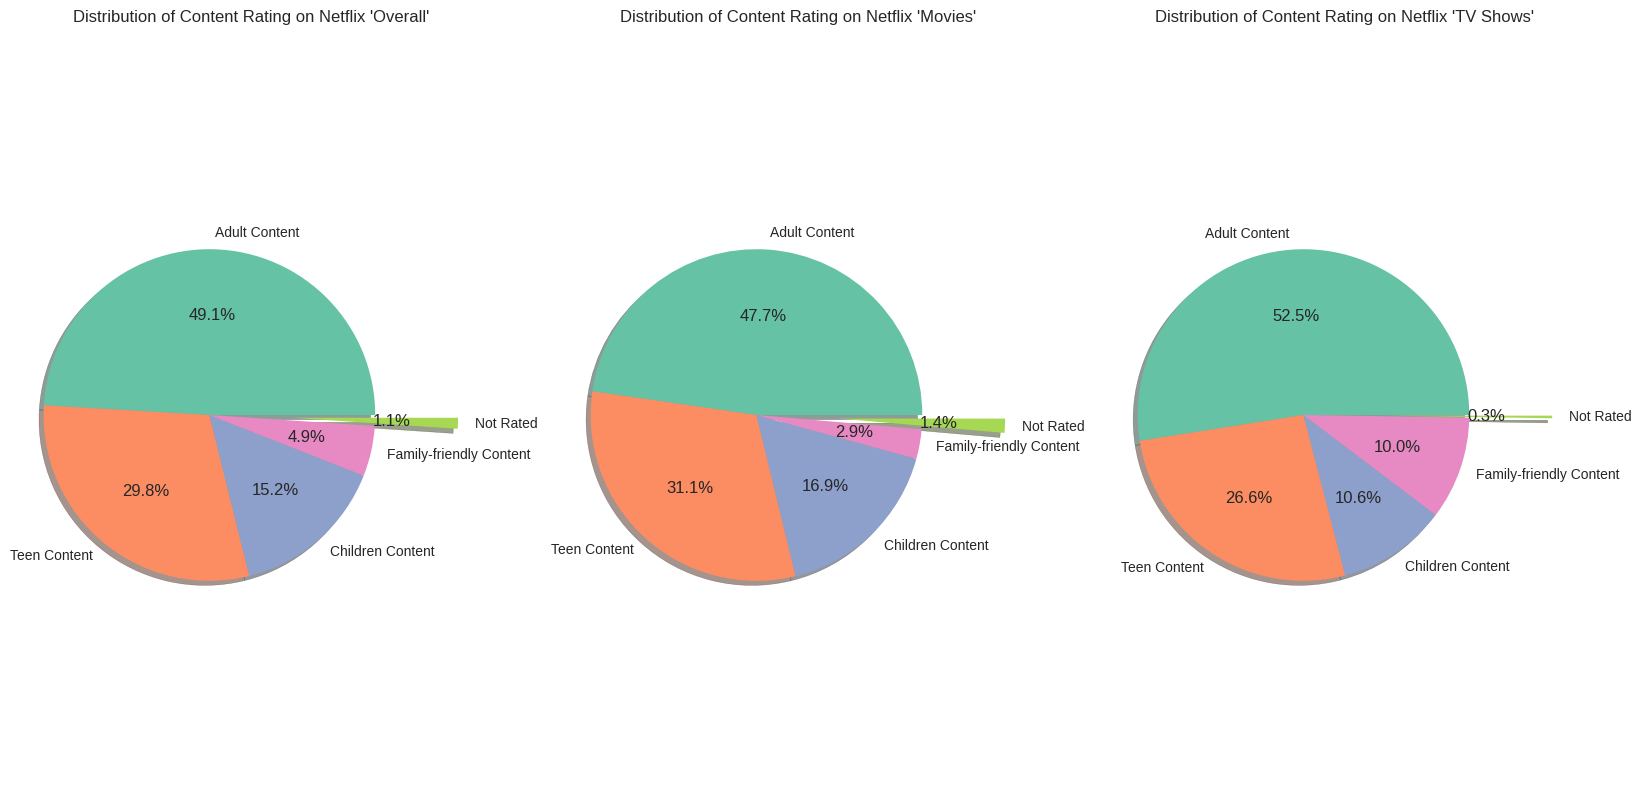

In [ ]:
# Chart - 2 visualization code
plt.figure(figsize=(20, 10))
datasets = [(df, 'Overall'), (df_movies, 'Movies'), (df_tvshows, 'TV Shows')]

for i, (data, label) in enumerate(datasets):
    plt.subplot(1, 3, i+1)
    count = data['rating'].value_counts()
    plt.pie(count, labels=count.index, autopct='%1.1f%%',explode=(0,0,0,0,0.5),colors=sns.color_palette("Set2"),shadow=True)
    plt.title(f"Distribution of Content Rating on Netflix '{label}'")
    plt.axis('equal')

plt.show()

##### 1. Why did you pick the specific chart?

A pie chart, was utilized to analyze the distribution of content types within Netflix. Its purpose was to determine the percentage of each content type (movies and TV shows) present on the platform.

##### 2. What is/are the insight(s) found from the chart?

* The analysis revealed that the majority of content available on Netflix falls under the Adult and Teen categories. These two categories constitute a significant portion of the content library.

* A noteworthy finding is that, in comparison to TV shows, there is a relatively lower presence of family-friendly content in the Movies category on Netflix. This suggests that TV shows offer a greater selection of content suitable for family viewing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The gained insights regarding the content distribution on Netflix, specifically the prevalence of Adult and Teen categories and the disparity in family-friendly content between Movies and TV Shows, can potentially create a positive business impact. By catering to the preferences of their target audience and strategically addressing the content gaps, Netflix can enhance user satisfaction, attract new subscribers, and ultimately drive business growth and success.



#### Chart - 3

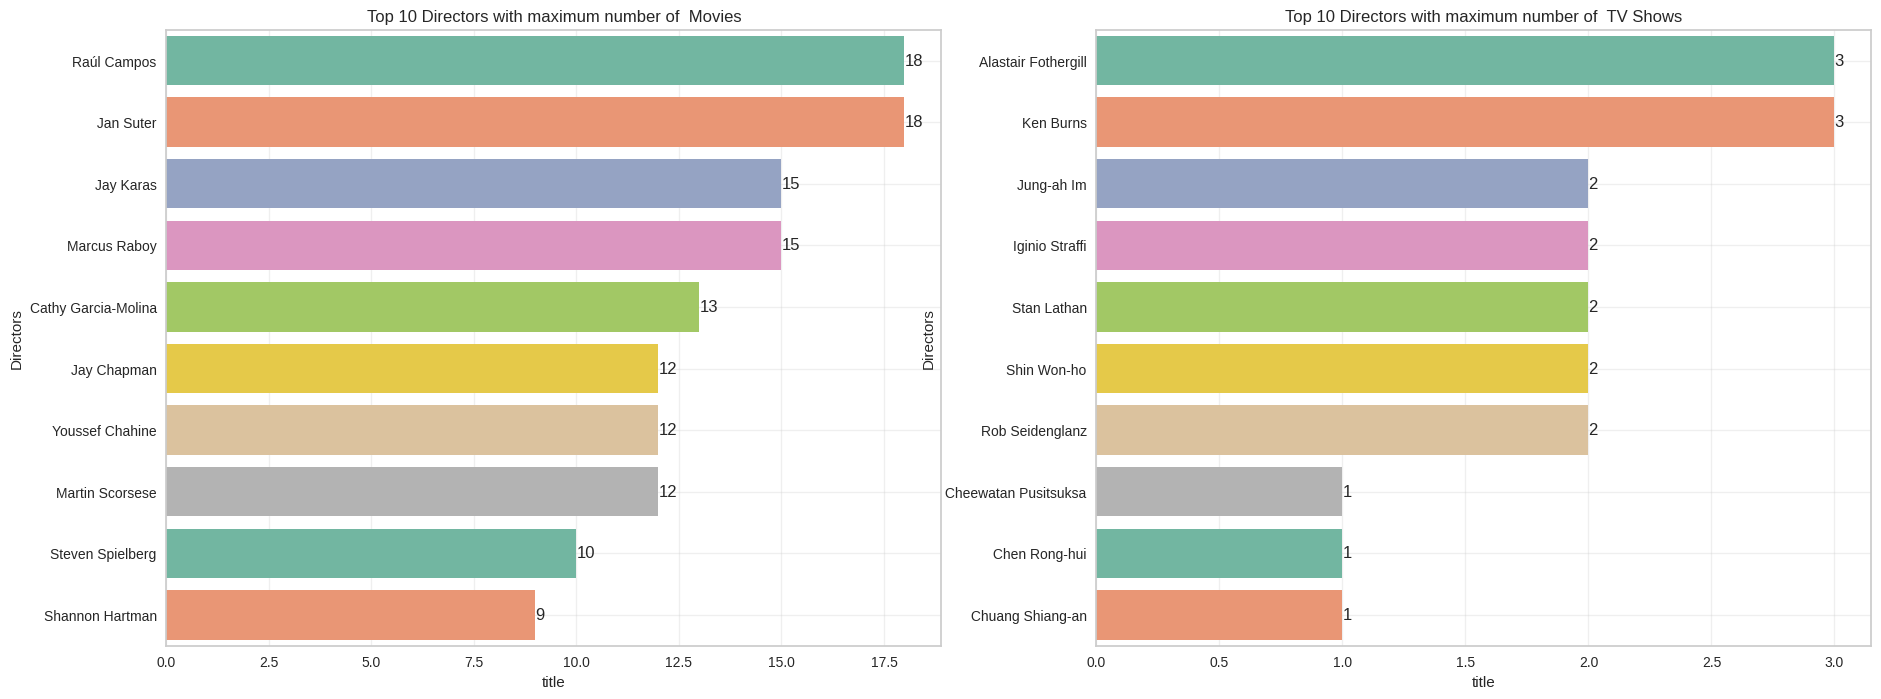

In [ ]:
# Chart - 3 visualization code
plt.figure(figsize=(22,8))
for i,j,k in (df_movies,'Movies',1),(df_tvshows,'TV Shows',2):
  plt.subplot(1,2,k)
  k=sns.barplot(y='Directors',x='title',data=i.groupby(['Directors']).nunique().sort_values(by='title',ascending=False).reset_index()[1:11],palette='Set2')
  for label in k.containers:
            k.bar_label(label)
  plt.grid(alpha=0.3)
  plt.title(f'Top 10 Directors with maximum number of  {j}')
plt.show()

##### 1. Why did you pick the specific chart?

To know about the most popular Directors in Movies and TV shows

##### 2. What is/are the insight(s) found from the chart?

* We found that most of the movies directed by **Raul Campos** and **Jan Suter**.

* Most TV shows directed by **Alastair Fothergill** and **ken burns**.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Movie/tvshows producers can select the popular director for their upcoming projects.

#### Chart - 4

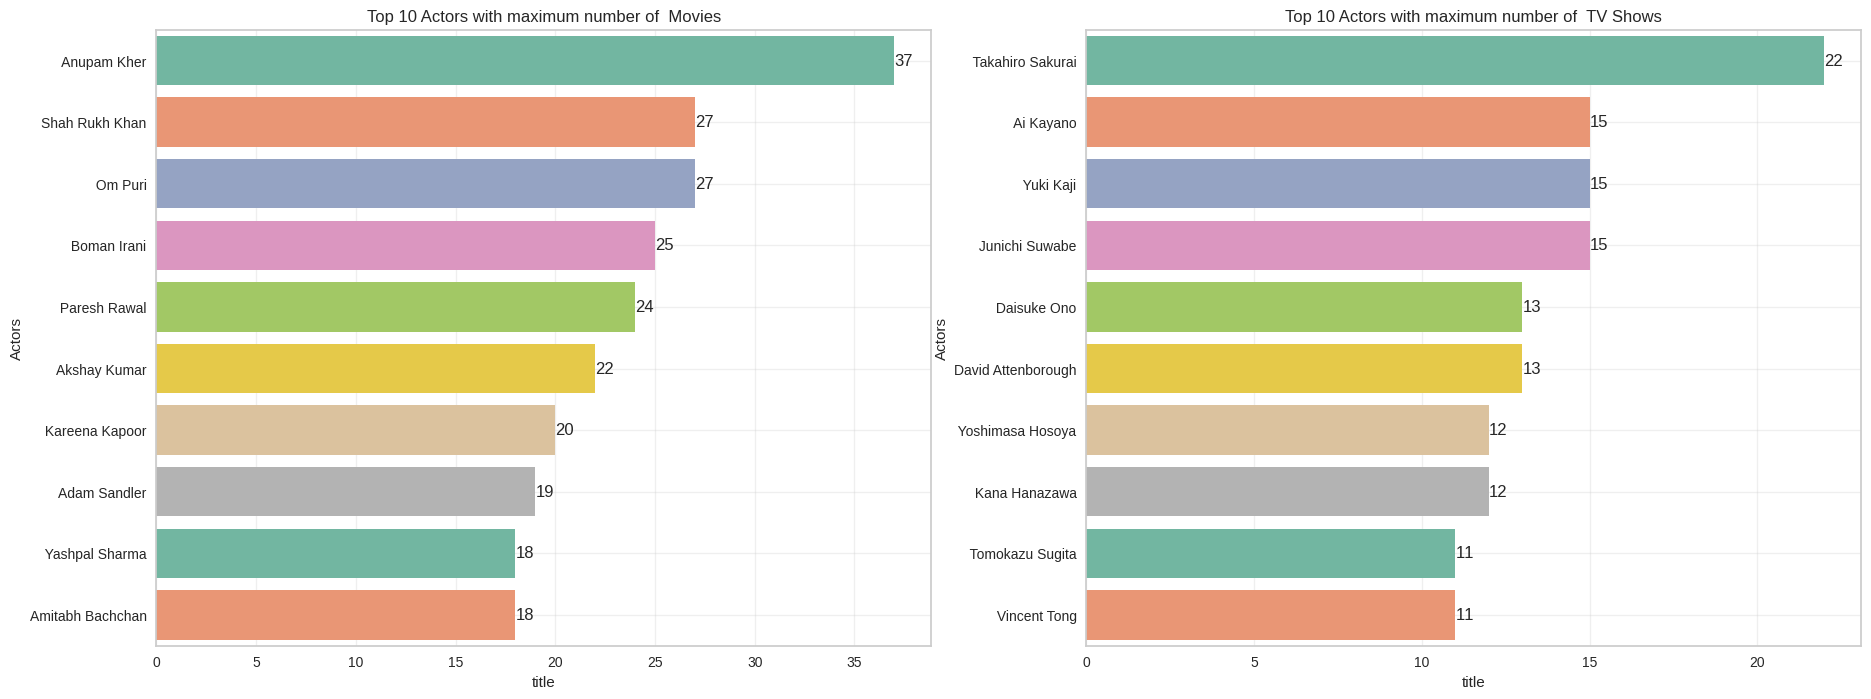

In [ ]:
# Chart - 4 visualization
plt.figure(figsize=(22,8))
for i,j,k in (df_movies,'Movies',1),(df_tvshows,'TV Shows',2):
  plt.subplot(1,2,k)
  k=sns.barplot(y='Actors',x='title',data=i.groupby('Actors').nunique().sort_values(by='title',ascending=False).reset_index()[1:11],palette='Set2')
  for label in k.containers:
            k.bar_label(label)
  plt.grid(alpha=0.3)
  plt.title(f'Top 10 Actors with maximum number of  {j}')
plt.show()


##### 1. Why did you pick the specific chart?

To know which actors are more popular on Netflix.

##### 2. What is/are the insight(s) found from the chart?

Insight: Majority of movie actors are from India, but no popular Indian actors found in TV shows.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Indian audience's passion for movies makes them a lucrative target market. Businesses should focus on capturing their attention and preferences to maximize viewership and commercial success.

#### Chart - 5

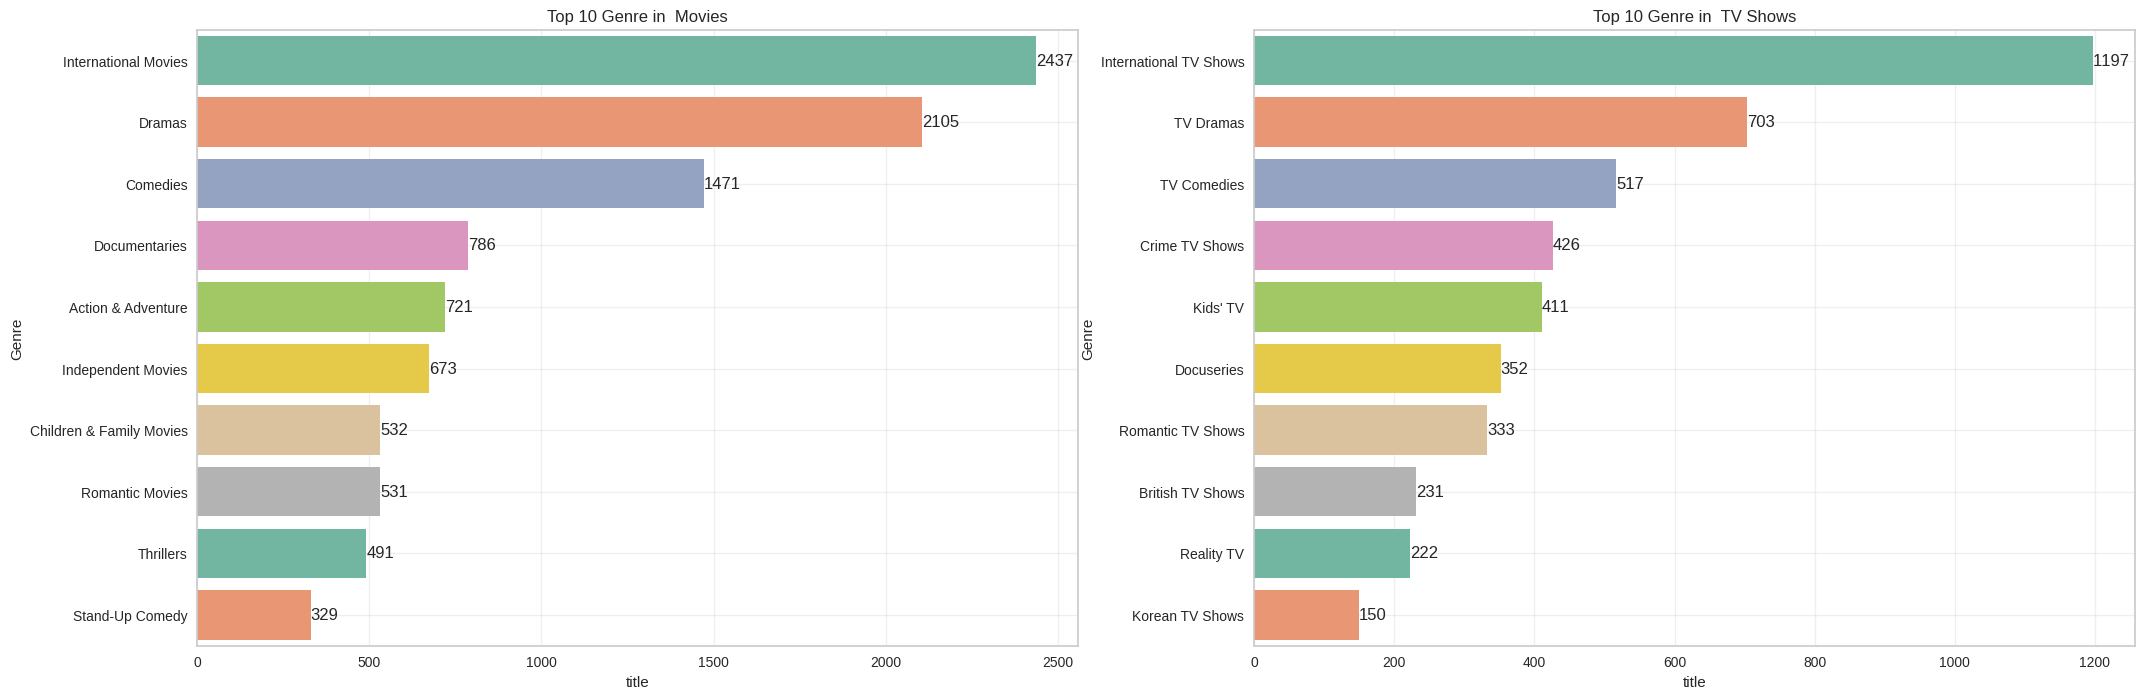

In [ ]:
# Chart - 5 visualization code
plt.figure(figsize=(25,8))
for i,j,k in (df_movies,'Movies',1),(df_tvshows,'TV Shows',2):
  plt.subplot(1,2,k)
  k=sns.barplot(y='Genre',x='title',data=i.groupby('Genre').nunique().sort_values(by='title',ascending=False).reset_index()[:10],palette='Set2')
  for label in k.containers:
            k.bar_label(label)
  plt.grid(alpha=0.3)
  plt.title(f'Top 10 Genre in  {j}')
plt.show()


##### 1. Why did you pick the specific chart?

To know which genre is more popular w.r.t movies/TV shows on Netflix

##### 2. What is/are the insight(s) found from the chart?

International movies/TV shows genre is most popular in both the Movies and TV Shows category. Followed by Drama and comedy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The gained insights about the popularity of international movies/TV shows, as well as drama and comedy genres, can potentially create a positive business impact. By aligning content production and marketing strategies to cater to these preferences, businesses can attract a larger audience and potentially boost profitability and market share.

#### Chart - 6

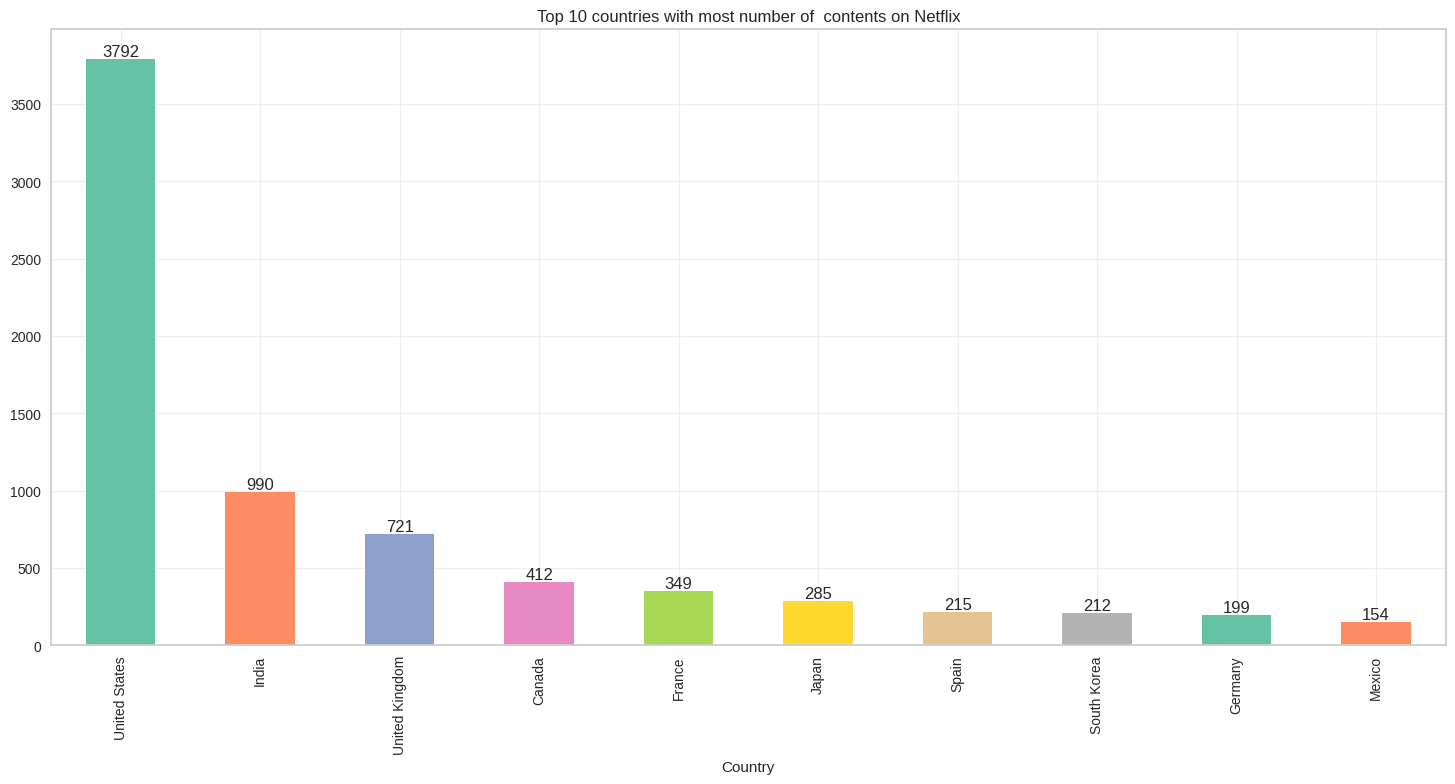

In [ ]:
# Chart - 6 visualization code
plt.figure(figsize=(18,8))
ax=df.groupby(['Country'])['title'].nunique().sort_values(ascending=False)[:10].plot(kind='bar',color=sns.color_palette('Set2'))
for label in ax.containers:
            ax.bar_label(label)
plt.grid(alpha=0.3)
plt.title('Top 10 countries with most number of  contents on Netflix')
plt.show()

##### 1. Why did you pick the specific chart?

To know which country contribute maximum number of contents on Netflix.

##### 2. What is/are the insight(s) found from the chart?

United States at the top followed by India in terms of most number of content contributor on Netflix.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The gained insights about the United States and India being the top contributors of content on Netflix can have a positive business impact. Understanding the content origins allows businesses to tailor their strategies to effectively cater to the preferences of these countries, potentially leading to increased viewership, subscriber retention, and revenue generation in these key markets

#### Chart - 7

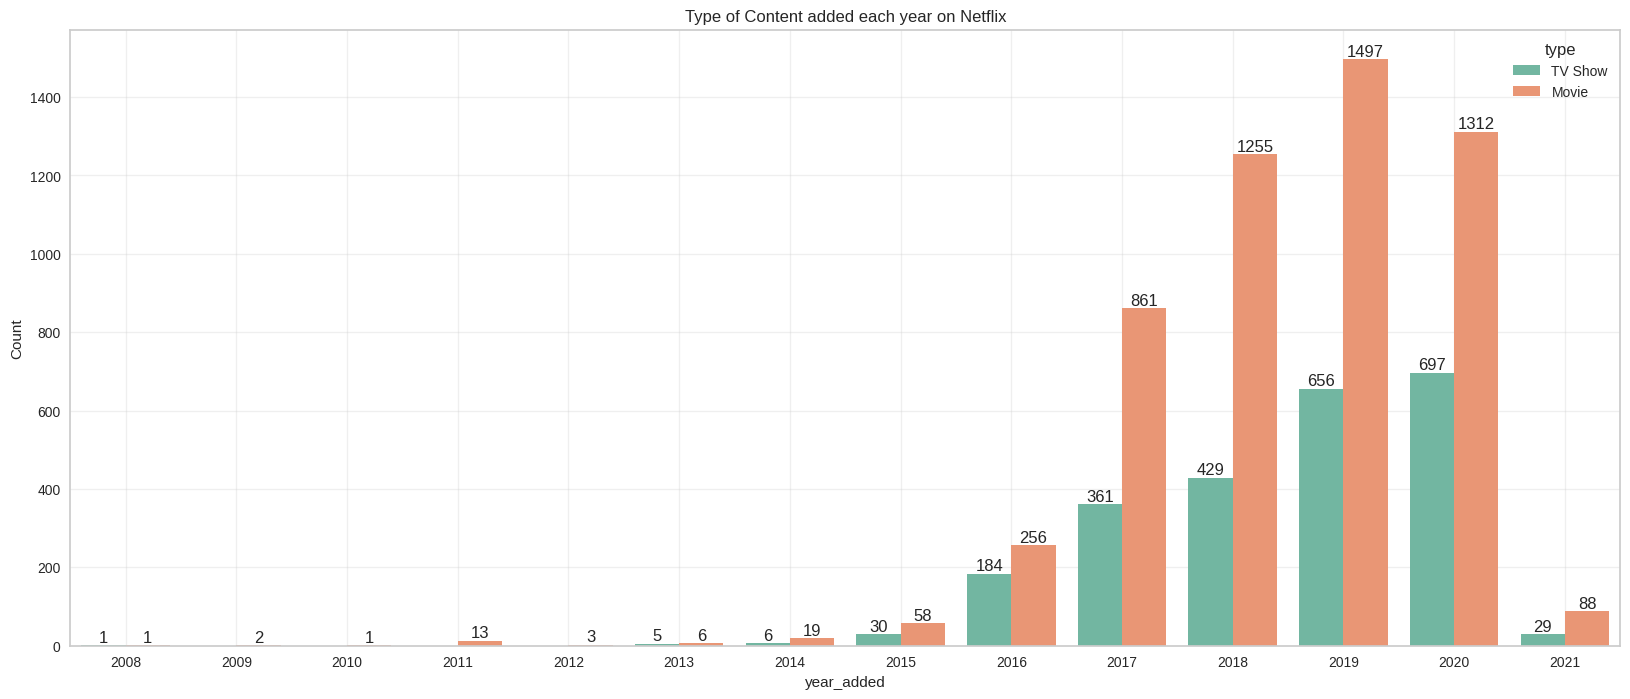

In [ ]:
# Chart - 7 visualization code
plt.figure(figsize=(20,8))
ax=sns.barplot(x='year_added',y='title',data=df.groupby(['year_added','type']).agg({'title':'nunique'}).reset_index().sort_values(by='title',ascending=False),hue='type',palette='Set2')
plt.grid(alpha=0.3)
plt.title('Type of Content added each year on Netflix')
plt.ylabel('Count')
for label in ax.containers:
            ax.bar_label(label)
plt.show()

##### 1. Why did you pick the specific chart?

To know about the Type of Content added each year on Netflix.

##### 2. What is/are the insight(s) found from the chart?

In terms of content additions, the year 2019 witnessed the highest number of movies being added to the platform, totaling 1497. Conversely, the year 2020 stands out for having the highest number of TV shows added, with a substantial count of 697. These insights highlight the significant growth and diversity of content offerings during those respective years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The gained insights about the highest number of movie and TV show additions in specific years can potentially create a positive business impact. By leveraging these trends, businesses can strategically plan their content acquisition and production strategies, ensuring a diverse and appealing library that caters to viewer preferences and drives engagement and subscriber growth.

#### Chart - 8

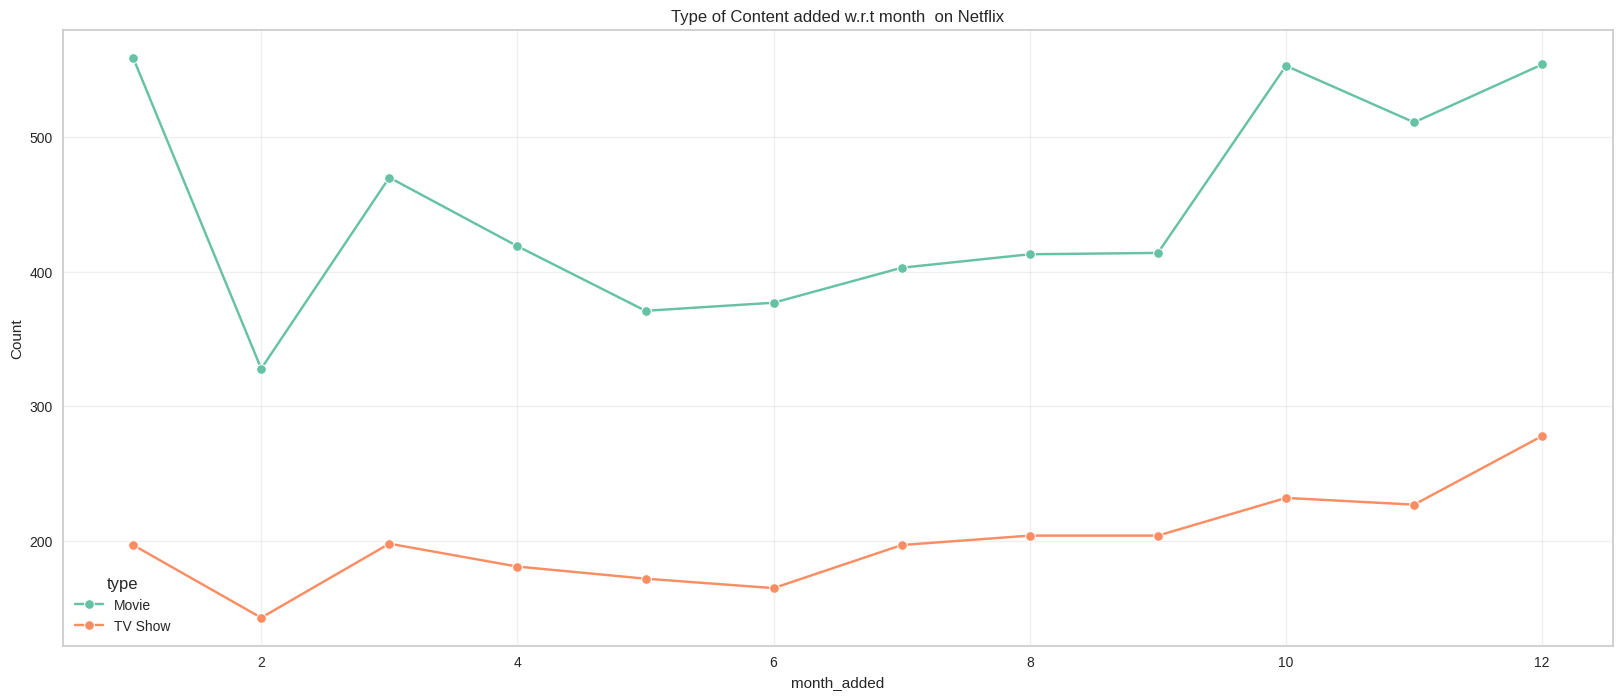

In [ ]:
# Chart - 8 visualization code
plt.figure(figsize=(20,8))
ax=sns.lineplot(x='month_added',y='title',data=df.groupby(['month_added','type']).agg({'title':'nunique'}).reset_index().sort_values(by='title',ascending=False),hue='type',palette='Set2', marker = 'o')
plt.grid(alpha=0.3)
plt.title('Type of Content added w.r.t month  on Netflix')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

The plot show Count of Movie/TV shows added each month.

##### 2. What is/are the insight(s) found from the chart?

The insights that show a high count of movies added to Netflix at the start and end of the year, as well as a high count of TV shows added in December, can inform strategic content acquisition decisions, leading to increased user engagement and subscriber retention.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights that show a high count of movies added to Netflix at the start and end of the year, as well as a high count of TV shows added in December, can inform strategic content acquisition decisions, leading to increased user engagement and subscriber retention.

#### Chart - 9

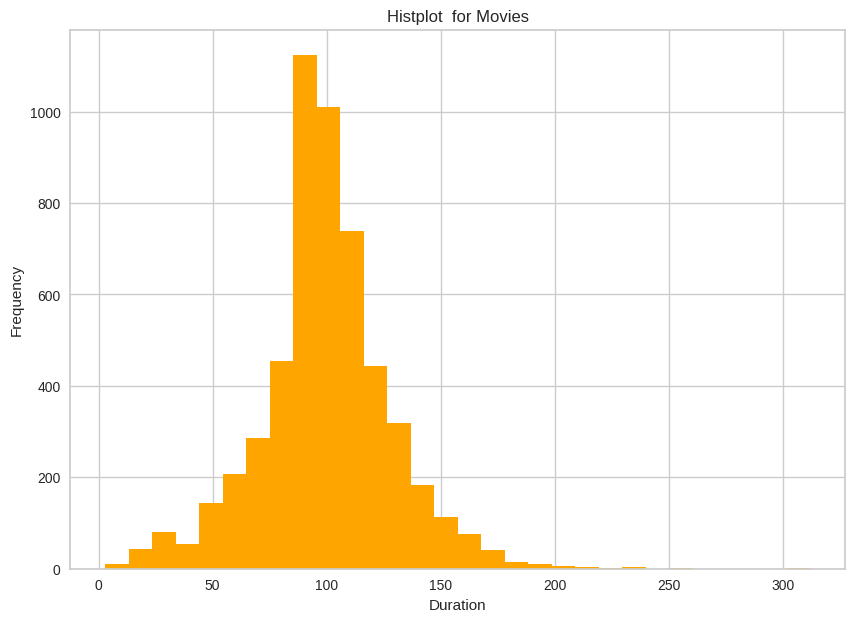

In [ ]:
# Chart - 9 visualization code
df1=df_movies.groupby('title').agg({'duration':'unique'}).reset_index()
df1['duration']=df1['duration'].apply(lambda x: x[0])
plt.figure(figsize=(10,7))
plt.title('Histplot  for Movies')
plt.hist(df1['duration'],color='orange',bins=30)
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

To Know about the duration distribution of movies.

##### 2. What is/are the insight(s) found from the chart?

Most of the Movies on Netflix fall under category of duration between 90 min to 120 min.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The gained insights about the majority of movies on Netflix falling within the duration of 90 to 120 minutes can help in curating and acquiring content that aligns with user preferences, leading to increased viewer satisfaction and engagement, thereby potentially creating a positive business impact.

#### Chart - 10 - Correlation Heatmap

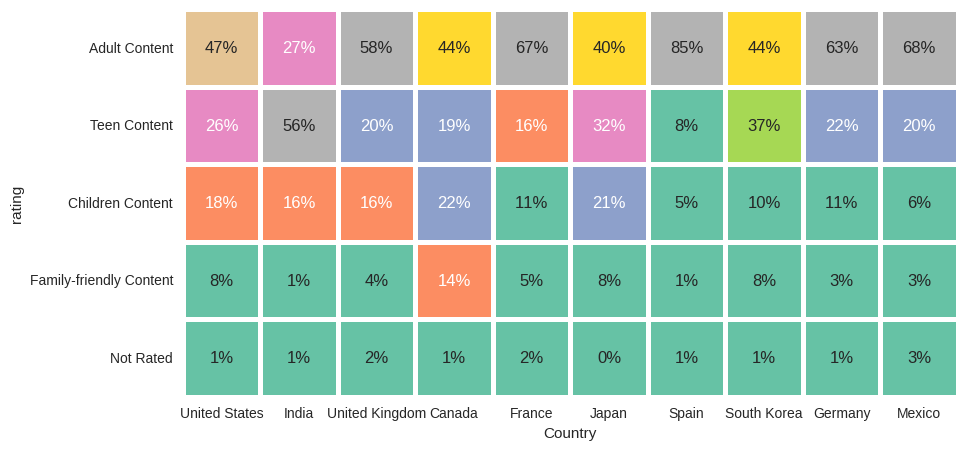

In [ ]:
# Correlation Heatmap visualization code
# Preparing data for heatmap
df['count'] = 1
data = df.groupby('Country')[['count']].sum().sort_values(by='count',ascending=False).reset_index()[:10]
data = data['Country']
df_heatmap = df.loc[df['Country'].isin(data)]
df_heatmap = pd.crosstab(df_heatmap['Country'],df_heatmap['rating'],normalize = "index").T

# Plotting the heatmap
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Defining order of representation
country_order = ['United States','India','United Kingdom','Canada','France','Japan','Spain','South Korea','Germany', 'Mexico']
rating_order = ['Adult Content', 'Teen Content', 'Children Content', 'Family-friendly Content', 'Not Rated']

# calling and plotting heatmap
sns.heatmap(df_heatmap.loc[rating_order,country_order], cmap='Set2', square=True,linewidth=2.5,cbar=False,annot=True,fmt='1.0%',vmax=.6,vmin=0.05,ax=ax,annot_kws={"fontsize":12})
plt.show()

##### 1. Why did you pick the specific chart?

This graph shows us which countries producing which type of content the most.

##### 2. What is/are the insight(s) found from the chart?

* All  countries except India producing Adult Content in higher proportion.
* India producing high percentage of  Teen Content.
* Canada is in Top in terms of Family-friendly Content (if we compares to others).
* 85% of content is Adult content from spain.


#### Chart - 11 - Pair Plot

<Figure size 1500x800 with 0 Axes>

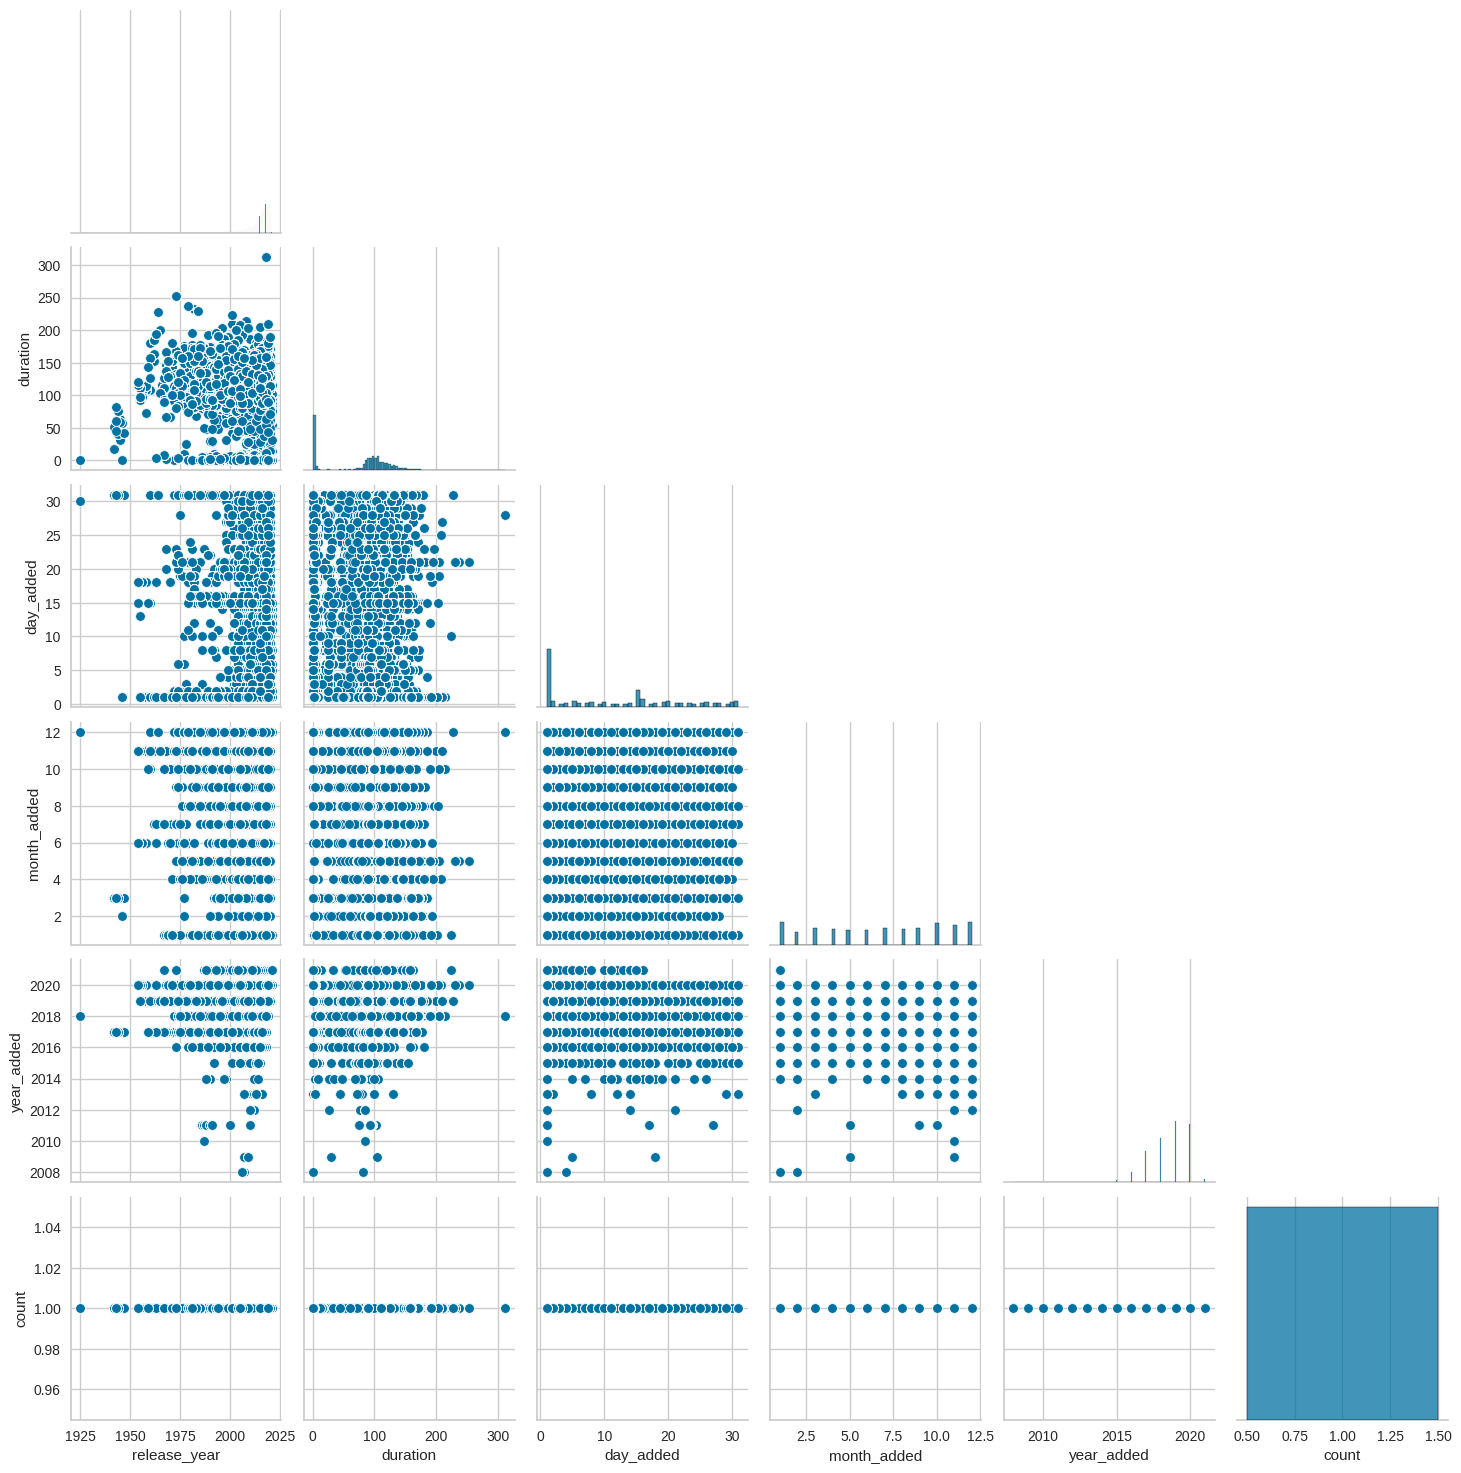

In [ ]:
# Pair Plot visualization code

plt.figure(figsize=(15,8))
sns.pairplot(df, corner=True)
plt.show()

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis**: There is no significant difference in the proportion ratings of drama movies and comedy movies on Netflix.

**Alternative Hypothesis**: There is a significant difference in the proportion ratings of drama movies and comedy movies on Netflix.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from statsmodels.stats.proportion import proportions_ztest
# Subset the data to only include drama and comedy movies
subset = df[df['Genre'].str.contains('Dramas') | df['Genre'].str.contains('Comedies')]

# Calculate the proportion of drama and comedy movies
drama_prop = len(subset[subset['Genre'].str.contains('Dramas')]) / len(subset)
comedy_prop = len(subset[subset['Genre'].str.contains('Comedies')]) / len(subset)

# Set up the parameters for the z-test
count = [int(drama_prop * len(subset)), int(comedy_prop * len(subset))]
nobs = [len(subset), len(subset)]
alternative = 'two-sided'

# Perform the z-test
z_stat, p_value = proportions_ztest(count = count, nobs = nobs, alternative = alternative)
print('z-statistic: ', z_stat)
print('p-value: ', p_value)

# Set the significance level
alpha = 0.05

# Print the results of the z-test
if p_value < alpha:
    print(f"Reject the null hypothesis.")
else:
    print(f"Fail to reject the null hypothesis.")



z-statistic:  64.8000705213286
p-value:  0.0
Reject the null hypothesis.


We conclude that there is a significant difference in the proportion ratings of drama movies and comedy movies on Netflix.

##### Which statistical test have you done to obtain P-Value?

The statistical test we have used to obtain the P-value is the z-test for proportions.

##### Why did you choose the specific statistical test?

The z-test for proportions is utilized when we need to compare the proportions of two categorical variables, specifically drama movies and comedy movies, within a given sample. The objective is to assess whether the observed disparity in proportions is statistically significant or merely due to chance. This statistical test is chosen because it enables us to evaluate the likelihood of observing the observed difference in proportions in our sample, assuming the null hypothesis to be true. In simpler terms, it allows us to determine if the difference between the two proportions is meaningful or just a result of random variation.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis**: The average duration of TV shows added in the year 2020 on Netflix is not significantly different from the average duration of TV shows added in the year 2021.

**Alternative Hypothesis**: The average duration of TV shows added in the year 2020 on Netflix is significantly different from the average duration of TV shows added in the year 2021.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
# To test this hypothesis, we perform a two-sample t-test.
from scipy.stats import ttest_ind

# Create separate dataframes for TV shows in 2020 and 2021
tv_2020 = df[(df['type'] == 'TV Show') & (df['release_year'] == 2020)]
tv_2021 = df[(df['type'] == 'TV Show') & (df['release_year'] == 2021)]

# Perform two-sample t-test
t, p = ttest_ind(tv_2020['duration'].astype(int),
                 tv_2021['duration'].astype(int), equal_var=False)
print('t-value: ', t)
print('p-value: ', p)

# Print the results
if p < 0.05:
    print('Reject null hypothesis. \nThe average duration of TV shows added in the year 2020 on Netflix is significantly different from the average duration of TV shows added in the year 2021.')
else:
    print('Failed to reject null hypothesis. \nThe average duration of TV shows added in the year 2020 on Netflix is not significantly different from the average duration of TV shows added in the year 2021.')



t-value:  -6.002151232542292
p-value:  7.23381843379902e-09
Reject null hypothesis. 
The average duration of TV shows added in the year 2020 on Netflix is significantly different from the average duration of TV shows added in the year 2021.


##### Which statistical test have you done to obtain P-Value?

The statistical test used to obtain the P-Value is a two-sample t-test.

##### Why did you choose the specific statistical test?

The two-sample t-test was chosen because we are comparing the means of two different samples (TV shows added in 2020 vs TV shows added in 2021) to determine whether they are significantly different. Additionally, we assume that the two samples have unequal variances since it is unlikely that the duration of TV shows added in 2020 and 2021 would have the exact same variance.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

The number of movies on Netflix is greater than the number of TV shows.
*   Null hypothesis H0:  The number of movies and TV shows on Netflix is not significantly different.

*   Alternate hypothesis Ha: The number of movies on Netflix is significantly greater than the number of TV shows.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from statsmodels.stats.proportion import proportions_ztest
# Count the number of movies and TV shows
n_movies = df[df['type'] == 'Movie'].count()['type']
n_tv_shows = df[df['type'] == 'TV Show'].count()['type']

# Set the counts and sample sizes for the z-test
counts = [n_movies, n_tv_shows]
nobs = [len(df), len(df)]

# Perform the z-test assuming equal proportions
z_stat, p_val = proportions_ztest(counts, nobs, value=0, alternative='larger')

# Print the results
print('Number of movies:', n_movies)
print('Number of TV shows:', n_tv_shows)
print('z-statistic:', z_stat)
print('p-value:', p_val)


Number of movies: 126079
Number of TV shows: 49728
z-statistic: 257.52040449203906
p-value: 0.0


##### Which statistical test have you done to obtain P-Value?

I used a two-sample z-test for proportions to obtain the p-value. The null hypothesis for the test is that the proportion of movies and TV shows on Netflix is equal, while the alternative hypothesis is that the proportion of movies is greater than the proportion of TV shows.

##### Why did you choose the specific statistical test?

I choose the two-sample z-test for proportions to compare the number of movies and TV shows on Netflix because the data consists of two categorical variables (Movies and TV show), and we want to test if there is a significant difference between the proportions of these categories in the population. The two-sample z-test for proportions is an appropriate test to use when we have two independent samples, and we want to compare the proportion of successes in each sample. In this case, a success refers to a movie or TV show. The test assumes that the samples are large enough to apply the normal approximation to the binomial distribution. Since we have a large sample size in this case, we can use the z-test for proportions to test the hypothesis of interest.



## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
df.isna().sum()

,0
title,0
Actors,0
Directors,0
Genre,0
Country,0
type,0
release_year,0
rating,0
duration,0
description,0


No Null Values found.

In [ ]:
df.head()

,title,Actors,Directors,Genre,Country,type,release_year,rating,duration,description,day_added,month_added,year_added,count
0,3%,João Miguel,Unknown,International TV Shows,Brazil,TV Show,2020,Adult Content,4,In a future where the elite inhabit an island ...,14,8,2020,1
1,3%,João Miguel,Unknown,TV Dramas,Brazil,TV Show,2020,Adult Content,4,In a future where the elite inhabit an island ...,14,8,2020,1
2,3%,João Miguel,Unknown,TV Sci-Fi & Fantasy,Brazil,TV Show,2020,Adult Content,4,In a future where the elite inhabit an island ...,14,8,2020,1
3,3%,Bianca Comparato,Unknown,International TV Shows,Brazil,TV Show,2020,Adult Content,4,In a future where the elite inhabit an island ...,14,8,2020,1
4,3%,Bianca Comparato,Unknown,TV Dramas,Brazil,TV Show,2020,Adult Content,4,In a future where the elite inhabit an island ...,14,8,2020,1


### 2. Handling Outliers

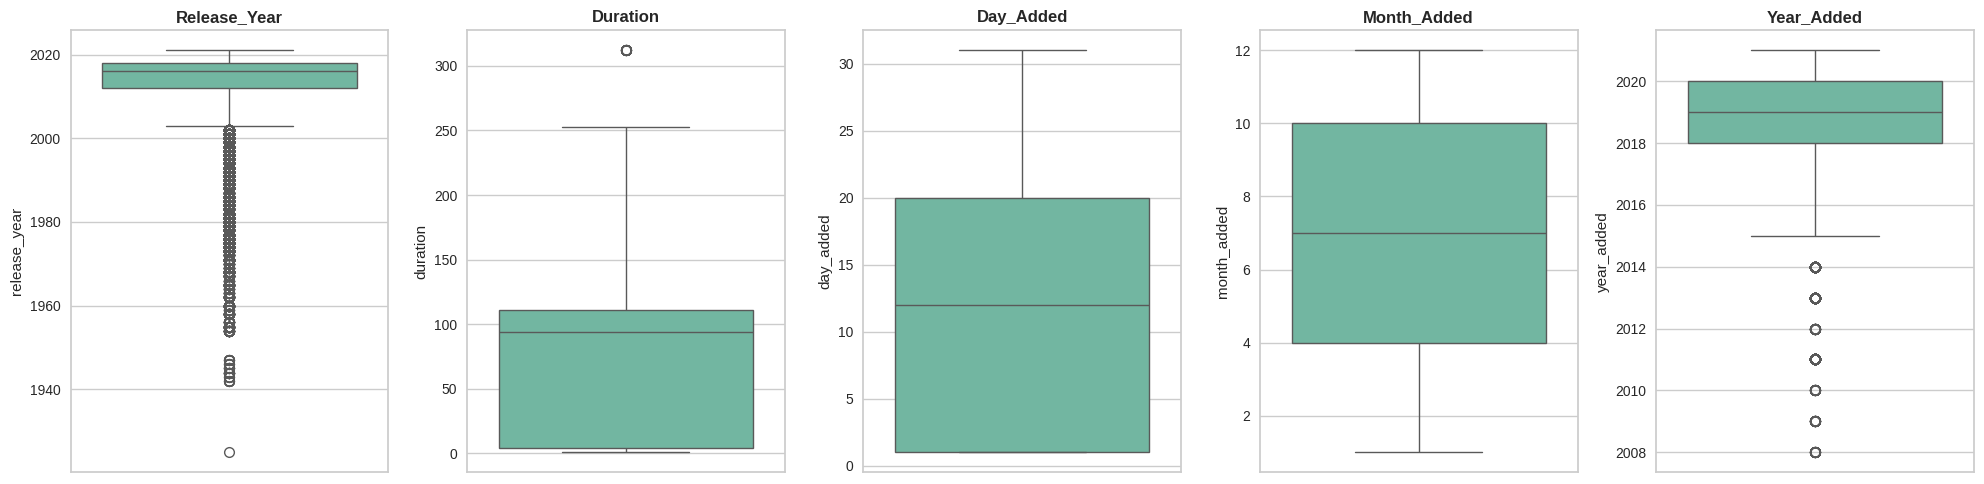

In [ ]:
# Handling Outliers & Outlier treatments
numeric_features=["release_year","duration","day_added","month_added","year_added"]
plt.figure(figsize=(20,5))
for i,column in enumerate(numeric_features):
  plt.subplot(1,5,i+1)
  sns.boxplot(df[column],palette='Set2')
  plt.title(f'{column.title()}',weight='bold')
  plt.tight_layout()


##### What all outlier treatment techniques have you used and why did you use those techniques?

While analyzing numeric features, it is common to encounter anomalies or outliers that deviate significantly from the majority of the data points. However, when examining features related to the release or addition of Movies/TV Shows on Netflix, we need to approach outliers differently.

In this scenario, some Movies/TV Shows may have been released or added to Netflix earlier than others, resulting in numeric values that appear as outliers. It is crucial not to dismiss these values as anomalies since they represent the unique nature of the data. These early releases or additions contribute valuable insights to our analysis and should not be treated as outliers to be excluded or treated separately.

By acknowledging and considering these unusual numeric values as valid and meaningful observations, we can gain a more comprehensive understanding of the release patterns and their impact on Netflix's content catalog.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [ ]:
df_new.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7527,s7528,Movie,Welcome to New York,Abel Ferrara,"Gérard Depardieu, Jacqueline Bisset, Marie Mou...","United States, France","March 23, 2017",2014,R,108 min,"Dramas, Independent Movies",A lecherous World Bank official sees his reput...
1179,s1180,TV Show,Call Me Francis,Unknown,"Rodrigo de la Serna, Sergio Hernández, Mercede...",Italy,"December 16, 2016",2016,TV-14,1 Season,"International TV Shows, Spanish-Language TV Sh...","On his path to becoming Pope Francis, Father J..."
7304,s7305,TV Show,Ultimate Beastmaster México,Unknown,"Luis Ernesto Franco, Inés Sainz, Tiki Barber, ...",United States,"August 31, 2018",2018,TV-PG,3 Seasons,"Reality TV, Spanish-Language TV Shows",Competitors representing countries from around...
2868,s2869,Movie,Hunter in the Blue Side of Manchester,Rako Prijanto,"Adipati Dolken, Ganindra Bimo, Donny Alamsyah,...","Indonesia, United Kingdom","July 3, 2020",2020,TV-MA,89 min,"Dramas, International Movies","To honor his father, a diligent college gradua..."
1446,s1447,Movie,Code 8,Jeff Chan,"Robbie Amell, Stephen Amell, Sung Kang, Kari M...",Canada,"April 11, 2020",2019,TV-MA,98 min,"Action & Adventure, Independent Movies, Intern...",In a city where super-powered people are ostra...


In [ ]:
#  Binning of rating in new dataframe
rating_map = {'TV-MA':'Adult Content',
              'R':'Adult Content',
              'PG-13':'Teen Content',
              'TV-14':'Teen Content',
              'TV-PG':'Children Content',
              'NR':'Not Rated',
              'TV-G':'Children Content',
              'TV-Y':'Family-friendly Content',
              'TV-Y7':'Family-friendly Content',
              'PG':'Children Content',
              'G':'Children Content',
              'NC-17':'Adult Content',
              'TV-Y7-FV':'Family-friendly Content',
              'UR':'Not Rated'}

df_new['rating'].replace(rating_map, inplace = True)
df_new['rating'].unique()

array(['Adult Content', 'Teen Content', 'Children Content', 'Not Rated',
       'Family-friendly Content'], dtype=object)

#### 1. Textual Columns

In [ ]:
# Creating new feature content_detail with the help of other textual attributes
df_new["content_detail"]= df_new["cast"]+" "+df_new["director"]+" "+df_new["listed_in"]+" "+df_new["type"]+" "+df_new["rating"]+" "+df_new["country"]+" "+df_new["description"]

#checking the manipulation
df_new.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_detail
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,Adult Content,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,"João Miguel, Bianca Comparato, Michel Gomes, R..."
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,Adult Content,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ..."
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,Adult Content,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...","Tedd Chan, Stella Chung, Henley Hii, Lawrence ..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,Teen Content,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...","Elijah Wood, John C. Reilly, Jennifer Connelly..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,Teen Content,123 min,Dramas,A brilliant group of students become card-coun...,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar..."


#### 2. Lower Casing

In [ ]:
# Lower Casing
df_new['content_detail']= df_new['content_detail'].str.lower()

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations
def remove_punctuations(text):
    '''This function is used to remove the punctuations from the given sentence'''
    #imorting needed library
    import string
    # replacing the punctuations with no space, which in effect deletes the punctuation marks.
    translator = str.maketrans('', '', string.punctuation)
    # return the text stripped off punctuation marks
    return text.translate(translator)

In [ ]:
# Removing Punctuations from the content_detail
df_new['content_detail']= df_new['content_detail'].apply(remove_punctuations)

# Checking the observation after manipulation
df_new.iloc[123,]['content_detail']

'andrei selaru dorian popa julia marcan ana radu cosmin nedelcu diana condurache andrei gavril luca bogdan matei dima comedies international movies movie teen content romania to keep the band together selly tries to earn money by making an appearance at the birthday party of a mobsters daughter — until he gets kidnapped'

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits
def remove_url_and_numbers(text):
    '''This function is used to remove the URL's and Numbers from the given sentence'''
    # importing needed libraries
    import re
    import string

    # Replacing the URL's with no space
    url_number_pattern = re.compile(r'https?://\S+|www\.\S+')
    text= re.sub(url_number_pattern,'', text)

    # Replacing the digits with one space
    text = re.sub('[^a-zA-Z]', ' ', text)

    # return the text stripped off URL's and Numbers
    return text


In [ ]:
# Remove URLs & Remove words and digits contain digits
df_new['content_detail']= df_new['content_detail'].apply(remove_url_and_numbers)

# Checking the observation after manipulation
df_new.iloc[123,]['content_detail']

'andrei selaru dorian popa julia marcan ana radu cosmin nedelcu diana condurache andrei gavril luca bogdan matei dima comedies international movies movie teen content romania to keep the band together selly tries to earn money by making an appearance at the birthday party of a mobsters daughter   until he gets kidnapped'

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
!pip install nltk
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
def remove_stopwords_and_whitespaces(text):
    '''This function is used for removing the stopwords from the given sentence'''
    text = [word for word in text.split() if not word in stopwords.words('english')]

    # joining the list of words with space separator
    text=  " ".join(text)

    # removing whitespace
    text = re.sub(r'\s+', ' ', text)

    # return the manipulated string
    return text

In [ ]:
df_new['content_detail']= df_new['content_detail'].apply(remove_stopwords_and_whitespaces)

# Checking the observation after manipulation
df_new.iloc[123,]['content_detail']

'andrei selaru dorian popa julia marcan ana radu cosmin nedelcu diana condurache andrei gavril luca bogdan matei dima comedies international movies movie teen content romania keep band together selly tries earn money making appearance birthday party mobsters daughter gets kidnapped'

#### 6. Tokenization

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

# Tokenization
# Tokenization
df_new['content_detail']= df_new['content_detail'].apply(nltk.word_tokenize)

# Checking the observation after manipulation
df_new.iloc[123,]['content_detail']

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['andrei',
 'selaru',
 'dorian',
 'popa',
 'julia',
 'marcan',
 'ana',
 'radu',
 'cosmin',
 'nedelcu',
 'diana',
 'condurache',
 'andrei',
 'gavril',
 'luca',
 'bogdan',
 'matei',
 'dima',
 'comedies',
 'international',
 'movies',
 'movie',
 'teen',
 'content',
 'romania',
 'keep',
 'band',
 'together',
 'selly',
 'tries',
 'earn',
 'money',
 'making',
 'appearance',
 'birthday',
 'party',
 'mobsters',
 'daughter',
 'gets',
 'kidnapped']

#### 7. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
# Downloading needed libraries
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')


# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import WordNetLemmatizer

# Creating instance for wordnet
wordnet  = WordNetLemmatizer()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
def lemmatizing_sentence(text):
    '''This function is used for lemmatizing (changing the given word into meaningfull word) the words from the given sentence'''
    text = [wordnet.lemmatize(word) for word in text]

    # joining the list of words with space separator
    text=  " ".join(text)

    # return the manipulated string
    return text

In [ ]:
# Rephrasing text by applying defined lemmatizing function
df_new['content_detail']= df_new['content_detail'].apply(lemmatizing_sentence)

# Checking the observation after manipulation
df_new.iloc[123,]['content_detail']

'andrei selaru dorian popa julia marcan ana radu cosmin nedelcu diana condurache andrei gavril luca bogdan matei dima comedy international movie movie teen content romania keep band together selly try earn money making appearance birthday party mobster daughter get kidnapped'

##### Which text normalization technique have you used and why?

We have used Lemmatization instead of Stemming for our project because:

1. **Lemmatization produces a more accurate base word**: Unlike Stemming, which simply removes the suffix from a word, Lemmatization looks at the meaning of the word and its context to produce a more accurate base form.

2. **Lemmatization can handle different inflections**: Lemmatization can handle various inflections of a word, including plural forms, verb tenses, and comparative forms, making it useful for natural language processing.

3. **Lemmatization produces real words**: Lemmatization always produces a real word that can be found in a dictionary, making it easier to interpret the results of text analysis.

4. **Lemmatization improves text understanding**: By reducing words to their base form, Lemmatization makes it easier to understand the context and meaning of a sentence.

5. **Lemmatization supports multiple languages**: While Stemming may only work well for English, Lemmatization is effective for many different languages, making it a more versatile text processing technique.

#### 8. Part of speech tagging

In [ ]:
import nltk

nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# POS Taging
# tokenize the text into words before POS Taging
df_new['pos_tags'] = df_new['content_detail'].apply(nltk.word_tokenize).apply(nltk.pos_tag)

# Checking the observation after manipulation
df_new.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_detail,pos_tags
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,Adult Content,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,jo miguel bianca comparato michel gomes rodolf...,"[(jo, NN), (miguel, NN), (bianca, NN), (compar..."
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,Adult Content,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,demi n bichir h ctor bonilla oscar serrano aza...,"[(demi, NN), (n, CC), (bichir, NN), (h, NN), (..."
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,Adult Content,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",tedd chan stella chung henley hii lawrence koh...,"[(tedd, NN), (chan, NN), (stella, NN), (chung,..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,Teen Content,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",elijah wood john c reilly jennifer connelly ch...,"[(elijah, RB), (wood, NN), (john, NN), (c, VBP..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,Teen Content,123 min,Dramas,A brilliant group of students become card-coun...,jim sturgess kevin spacey kate bosworth aaron ...,"[(jim, NN), (sturgess, NN), (kevin, NN), (spac..."


#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

# Creating instance
tfidfv = TfidfVectorizer(max_features=20000)

In [ ]:
# Fitting on TfidfVectorizer
x= tfidfv.fit_transform(df_new['content_detail'])

# Checking shape of the formed document matrix
print(x.shape)

(7770, 20000)


##### Which text vectorization technique have you used and why?

TF-IDF vectorization has been adopted instead of the traditional Bag of Words approach due to its ability to capture the significance of individual words within a document. By considering both term frequency and inverse document frequency, TF-IDF assigns greater weights to rare words that are exclusive to a specific document, thereby emphasizing their importance in the overall representation.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

The utilization of Principal Component Analysis (PCA) as a technique for dimensionality reduction has proven highly valuable. By identifying the principal components that encapsulate the maximum variation within the data, PCA effectively condenses high-dimensional datasets while preserving the essential information. This popular method is favoured for its simplicity, computational efficiency, and wide accessibility in data analysis software. Moreover, PCA's extensive study and robust theoretical foundation make it a reliable and well-established approach.

**PCA IMPLEMENTAION CODE**

In [ ]:
Dimensionality Reduction
Importing PCA from sklearn
from sklearn.decomposition import PCA
pca=PCA()
pca.fit(x.toarray())

variance= pca.explained_variance_ratio_
print(f"Explained variance: {variance}")



Explained variance: [1.58974677e-02 4.38102164e-03 3.56871992e-03 ... 1.13242710e-35
 4.87589267e-37 4.12241672e-37]


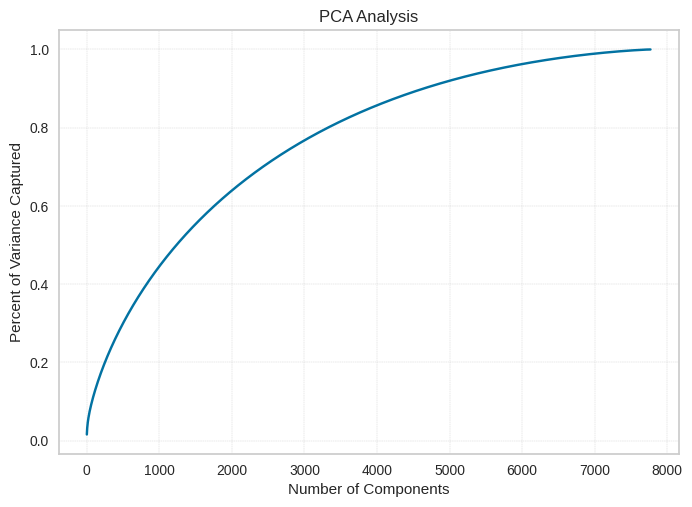

In [ ]:
# Ploting the percent of variance captured versus the number of components in order to determine the reduced dimensions
fig, ax = plt.subplots()
ax.plot(range(1, len(variance)+1), np.cumsum(pca.explained_variance_ratio_))
ax.set_xlabel('Number of Components')
ax.set_ylabel('Percent of Variance Captured')
ax.set_title('PCA Analysis')
plt.grid(linestyle='--', linewidth=0.3)
plt.show()

In [ ]:
# Now we are passing the argument so that we can capture 95% of variance.
# Defining instance
pca_tuned = PCA(n_components=0.95)

# Fitting and transforming the model
pca_tuned.fit(x.toarray())
x_transformed = pca_tuned.transform(x.toarray())

# Checking the shape of transformed matrix
x_transformed.shape

(7770, 5657)

**Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)** <br>
The utilization of Principal Component Analysis (PCA) as a technique for dimensionality reduction has proven highly valuable. By identifying the principal components that encapsulate the maximum variation within the data, PCA effectively condenses high-dimensional datasets while preserving the essential information. This popular method is favoured for its simplicity, computational efficiency, and wide accessibility in data analysis software. Moreover, PCA's extensive study and robust theoretical foundation make it a reliable and well-established approach.



## ***7. ML Model Implementation***

### ML Model - 1  (**K-Means Clustering**)

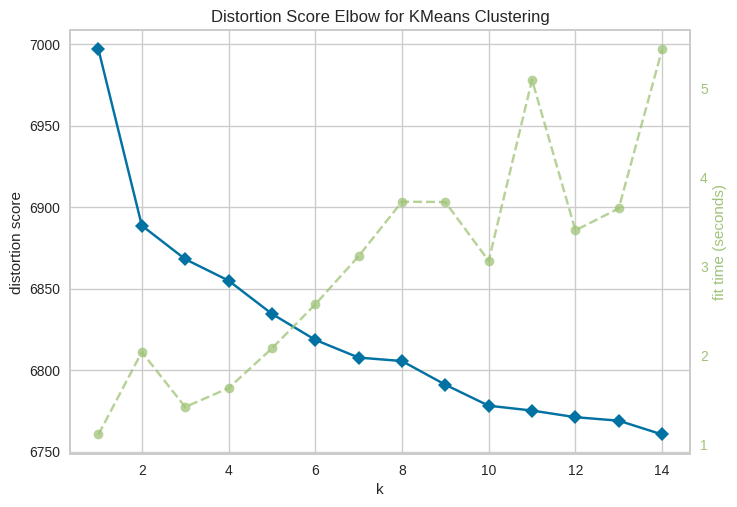

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Instantiate the clustering model and visualizer
model = KMeans(random_state=0)
visualizer = KElbowVisualizer(model,k=(1,15),locate_elbow=False)

visualizer.fit(x_transformed)
visualizer.show()

Here it seems that the elbow is forming at the 2 clusters but before blindly believing it let's plot one more chart that iterates over the same number of clusters and determines the Silhouette Score at every point.

The silhouette score is a measure of how similar an object is to its own cluster compared to other clusters. It is used to evaluate the quality of clustering, where a higher score indicates that objects are more similar to their own cluster and dissimilar to other clusters.

The silhouette score ranges from -1 to 1, where a score of 1 indicates that the object is well-matched to its own cluster, and poorly-matched to neighboring clusters. Conversely, a score of -1 indicates that the object is poorly-matched to its own cluster, and well-matched to neighboring clusters.

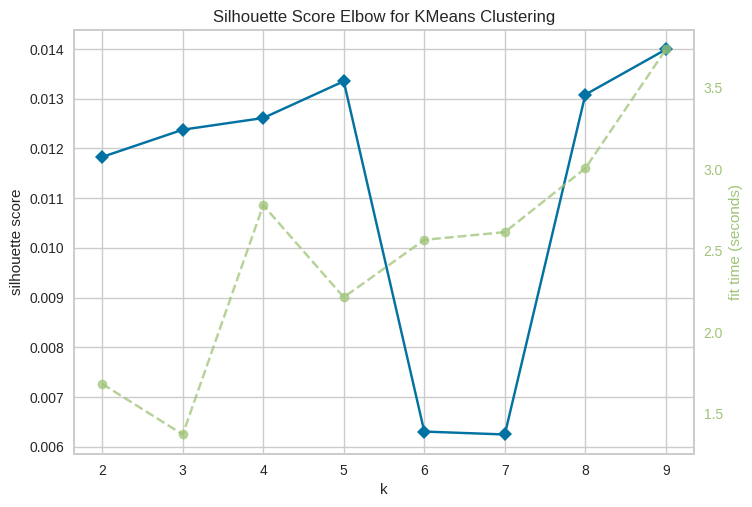

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Instantiate the clustering  visualizer
visualizer = KElbowVisualizer(model,k=(2,10),metric='silhouette',timings=True,locate_elbow=False)

visualizer.fit(x_transformed)
visualizer.show()

**Key Observations:**

* The silhouette score increases from k=2 to k=5, peaking around k=5, which suggests 5 clusters may be a good choice.

* The score drops significantly for k=6 and k=7, indicating poor clustering for those values.

* The score rises again for k=8 and k=9, but these may not be optimal due to increasing complexity and computational cost.

In [ ]:
 #Computing Silhouette score for each k
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

k_range = range(2, 7)
for k in k_range:
    Kmodel = KMeans(n_clusters=k, random_state=42)
    labels = Kmodel.fit_predict(x_transformed)
    score = silhouette_score(x_transformed, labels)
    print(f'k={k}, Silhouette score={score:.6f}')


k=2, Silhouette score=0.011829
k=3, Silhouette score=0.012084
k=4, Silhouette score=0.012197
k=5, Silhouette score=0.005709
k=6, Silhouette score=0.001580


From the above plots (Elbow plot and Sillhouette plot) it is very clear that the Silhoutte score is comparatively good for 4 number of clusters, so we will consider 4 cluster in kmeans analysis.

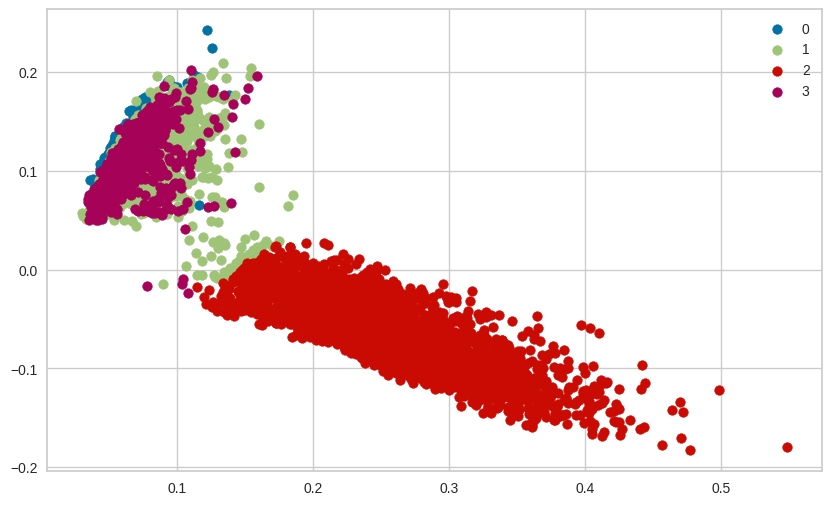

In [ ]:
#training the K-means model on a dataset
kmeans = KMeans(n_clusters=4, init='k-means++', random_state= 0)

#predict the labels of clusters.
plt.figure(figsize=(10,6), dpi=100)
label = kmeans.fit_predict(x_transformed)
#Getting unique labels
unique_labels = np.unique(label)

#plotting the results:
for i in unique_labels:
    plt.scatter(x_transformed[label == i , 0] , x_transformed[label == i , 1] , label = i)
plt.legend()
plt.show()

Let's plot the above figure in 3D using mplot3d library and see if we are getting the separated clusters.

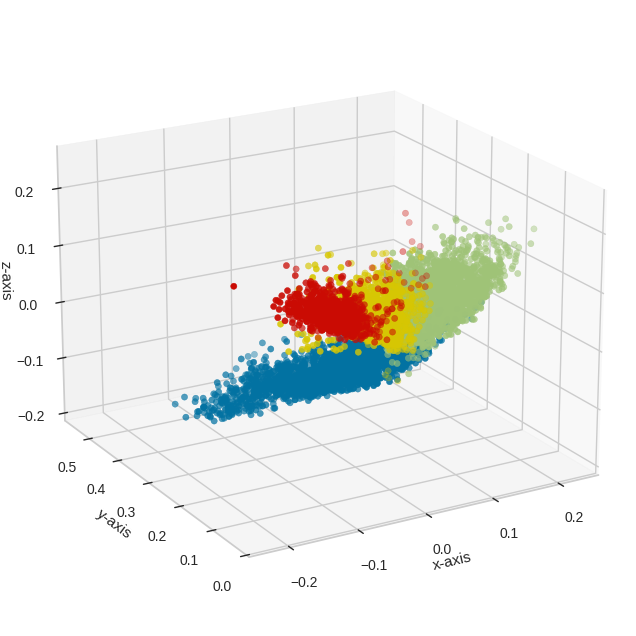

In [ ]:
# Importing library to visualize clusters in 3D
from mpl_toolkits.mplot3d import Axes3D

# Plot the clusters in 3D
fig = plt.figure(figsize=(20,8))
ax = fig.add_subplot(111, projection='3d')
colors = ['r', 'g', 'b', 'y']
for i in range(len(colors)):
    ax.scatter(x_transformed[kmeans.labels_ == i, 2], x_transformed[kmeans.labels_ == i, 0], x_transformed[kmeans.labels_ == i, 1], c=colors[i])

# Rotate the plot 30 degrees around the X axis and 45 degrees around the Z axis
ax.view_init(elev=20, azim=-120)
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-axis')
plt.show()

In [ ]:
# Add cluster values to the dateframe.
df_new['kmeans_cluster'] = kmeans.labels_

In [ ]:
df_new.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_detail,pos_tags,kmeans_cluster
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,Adult Content,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,jo miguel bianca comparato michel gomes rodolf...,"[(jo, NN), (miguel, NN), (bianca, NN), (compar...",2
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,Adult Content,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,demi n bichir h ctor bonilla oscar serrano aza...,"[(demi, NN), (n, CC), (bichir, NN), (h, NN), (...",3
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,Adult Content,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",tedd chan stella chung henley hii lawrence koh...,"[(tedd, NN), (chan, NN), (stella, NN), (chung,...",3
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,Teen Content,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",elijah wood john c reilly jennifer connelly ch...,"[(elijah, RB), (wood, NN), (john, NN), (c, VBP...",1
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,Teen Content,123 min,Dramas,A brilliant group of students become card-coun...,jim sturgess kevin spacey kate bosworth aaron ...,"[(jim, NN), (sturgess, NN), (kevin, NN), (spac...",1


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
def kmeans_wordcloud(cluster_number, column_name):
    '''function for Building a wordcloud for the movie/shows'''

    #Importing libraries
    from wordcloud import WordCloud, STOPWORDS

    # Filter the data by the specified cluster number and column name
    df_wordcloud = df_new[['kmeans_cluster', column_name]].dropna()
    df_wordcloud = df_wordcloud[df_wordcloud['kmeans_cluster'] == cluster_number]
    df_wordcloud = df_wordcloud[df_wordcloud[column_name].str.len() > 0]

    # Combine all text documents into a single string
    text = " ".join(word for word in df_wordcloud[column_name])

    # Create the word cloud
    wordcloud = WordCloud(stopwords=set(STOPWORDS)).generate(text)

    # Convert the wordcloud to a numpy array
    image_array = wordcloud.to_array()

    # Return the numpy array
    return image_array

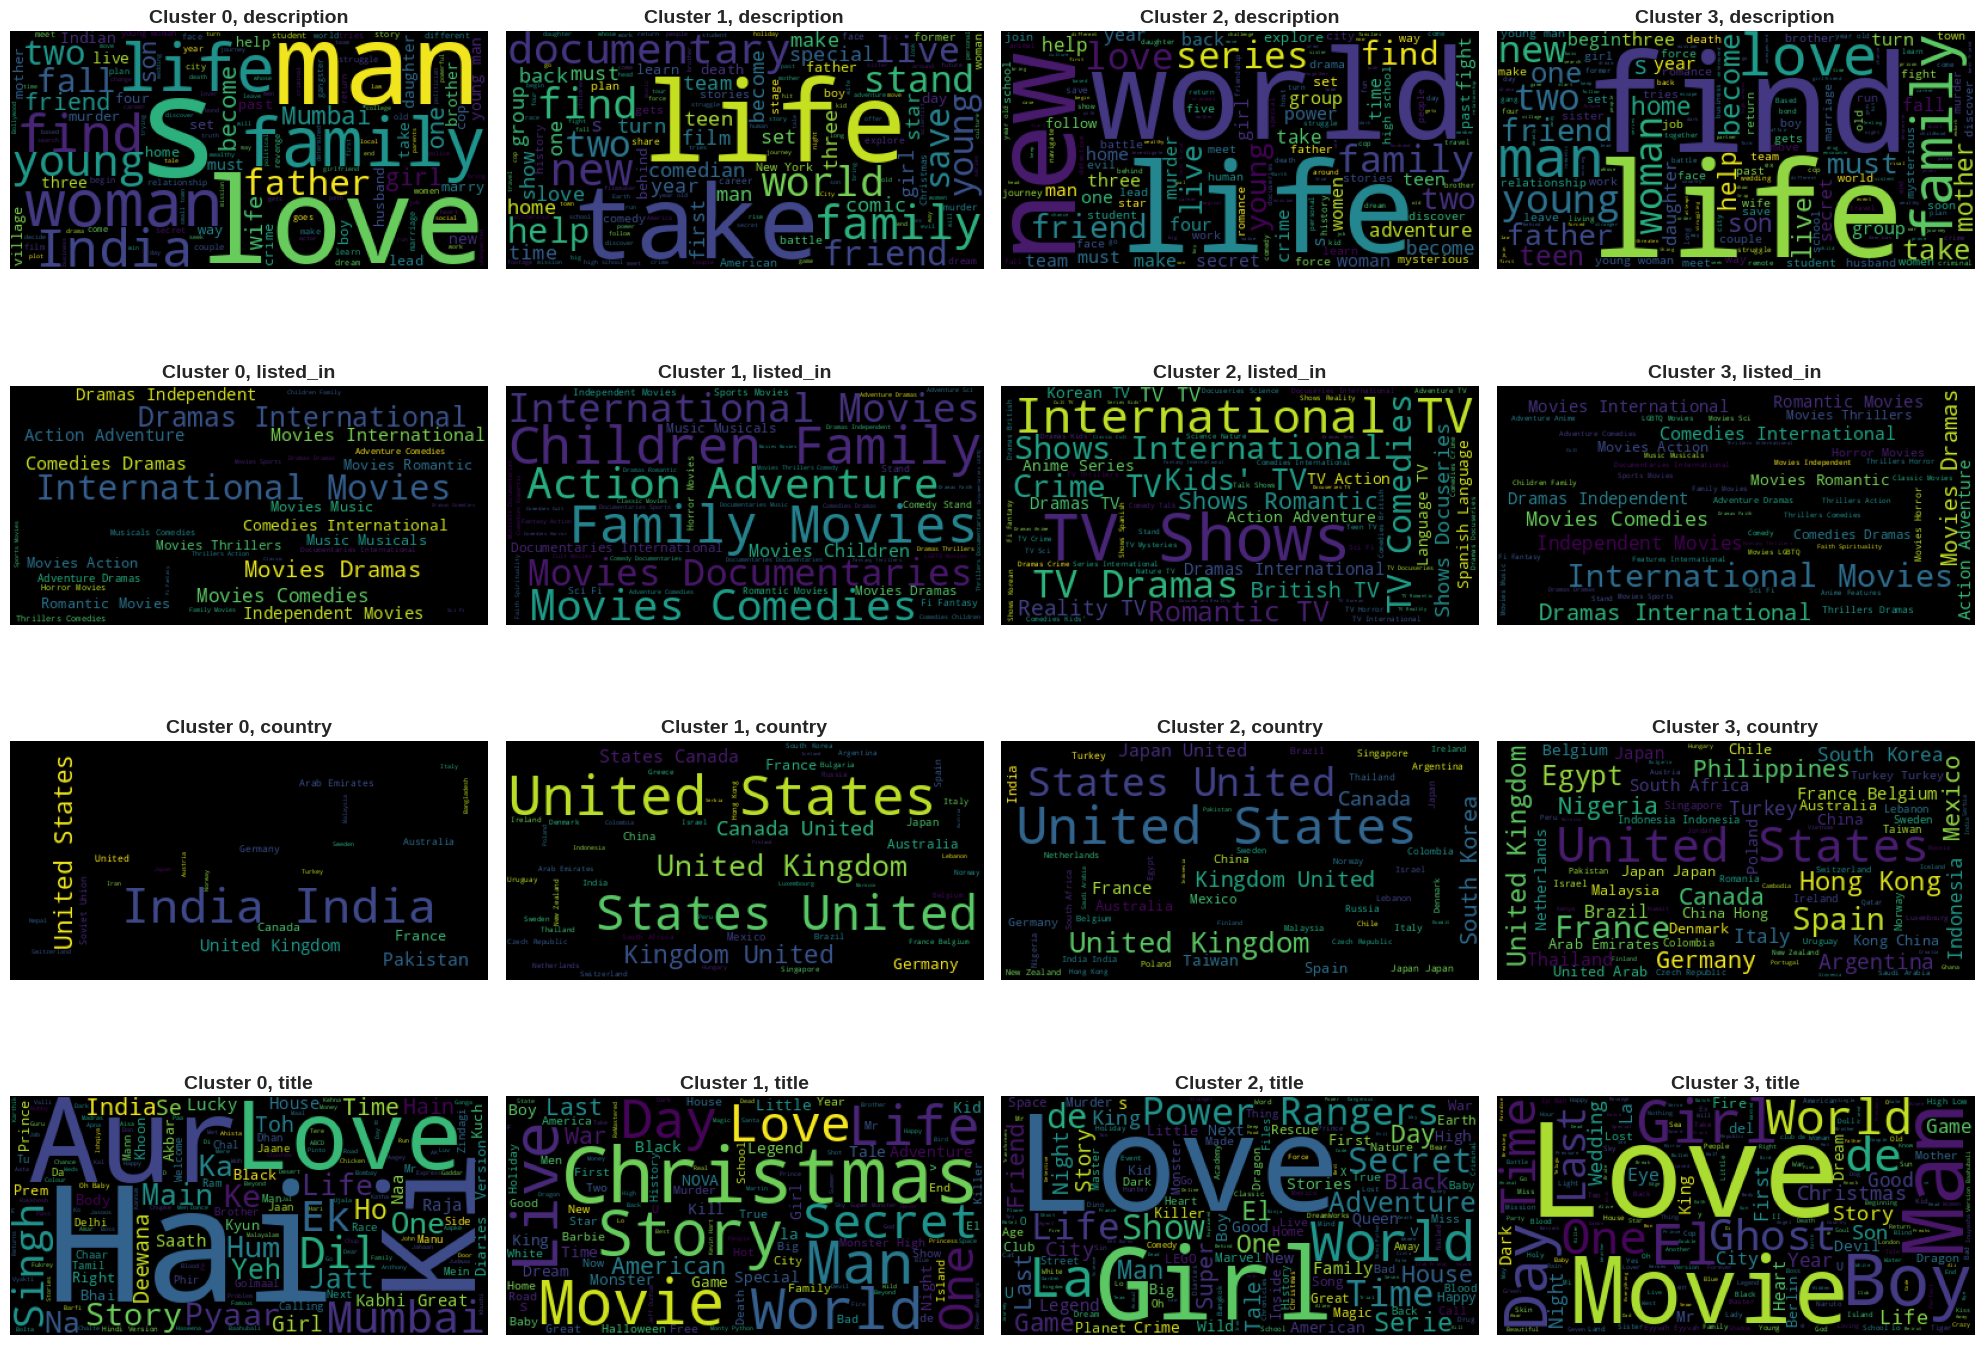

In [ ]:
# Implementing the above defined function and plotting the wordcloud of each attribute
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 15))
for i in range(4):
    for j, col in enumerate(['description', 'listed_in', 'country', 'title']):
        axs[j][i].imshow(kmeans_wordcloud(i, col))
        axs[j][i].axis('off')
        axs[j][i].set_title(f'Cluster {i}, {col}',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### ML Model - 2 (Hierarchial Clustering)

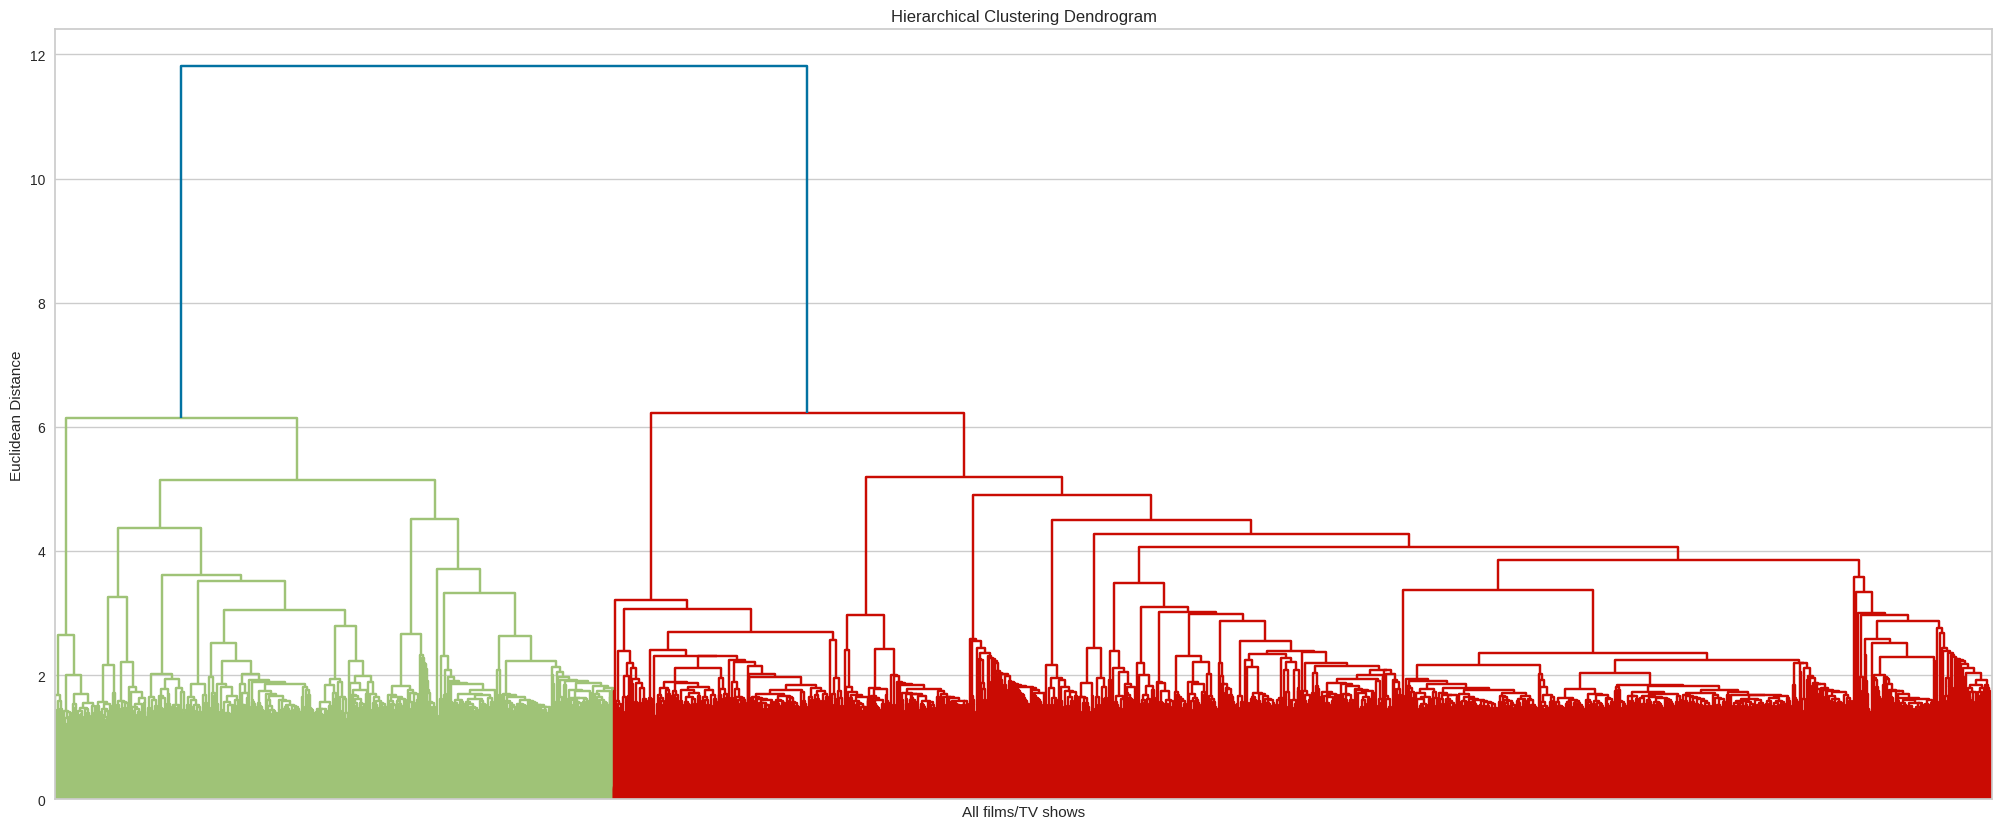

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# HIERARCHICAL CLUSTERING
distances_linkage = linkage(x_transformed, method = 'ward', metric = 'euclidean')
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('All films/TV shows')
plt.ylabel('Euclidean Distance')

dendrogram(distances_linkage, no_labels = True)
plt.show()

* A dendrogram is a tree-like diagram that records the sequences of merges or splits.More the distance of the vertical lines in the dendrogram, more the distance between those clusters.
* From the above Dendogram we can say that optimal value of clusters is 2. But before assigning the values to respective clusters, let's check the silhouette scores using Agglomerative clustering and follow the bottom up approach to aggregate the datapoints.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Range selected from dendrogram above
k_range = range(2,6)
for k in k_range:
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(x_transformed)
    score = silhouette_score(x_transformed, labels)
    print("k=%d, Silhouette score=%f" % (k, score))

k=2, Silhouette score=0.006228
k=3, Silhouette score=0.006865
k=4, Silhouette score=-0.002157
k=5, Silhouette score=-0.001290


From the above silhouette scores it is clear that the 2 clusters are optimal value (maximum Silhouette score), which is also clear from the above Dendogram that for 2 cluters the euclidean distances are maximum.

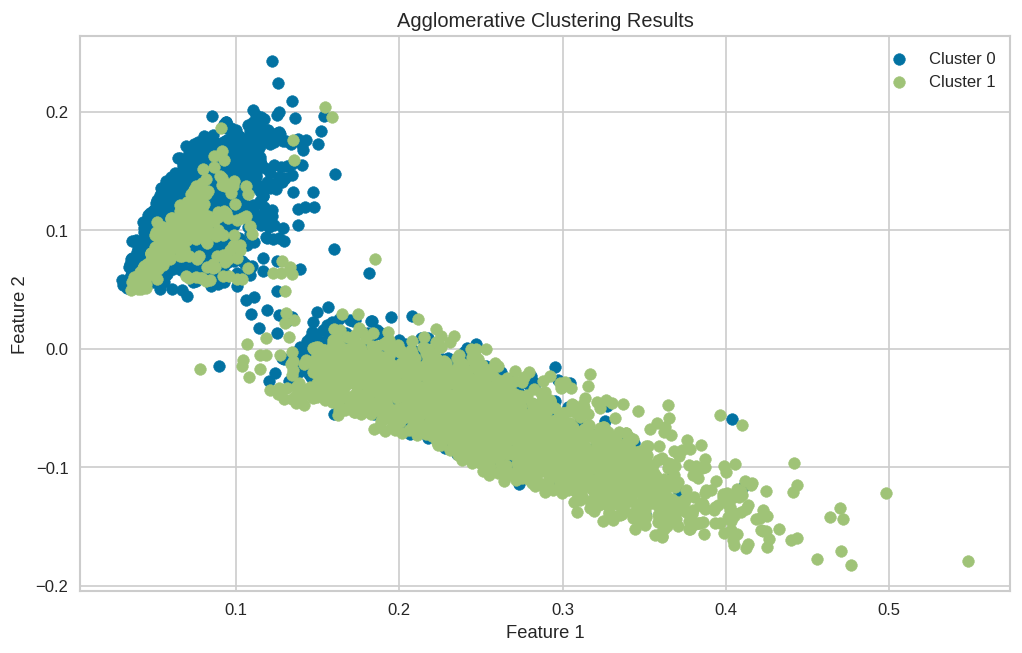

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt

# Train Agglomerative Clustering model
Agmodel = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')

# Predict cluster labels
label = Agmodel.fit_predict(x_transformed)

# Getting unique labels
unique_labels = np.unique(label)

# Plotting the results
plt.figure(figsize=(10,6), dpi=120)
for i in unique_labels:
    plt.scatter(x_transformed[label == i, 0], x_transformed[label == i, 1], label=f'Cluster {i}')

plt.legend()
plt.title("Agglomerative Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

plotting the 3 Dimensional plot to see the clusters clearly.

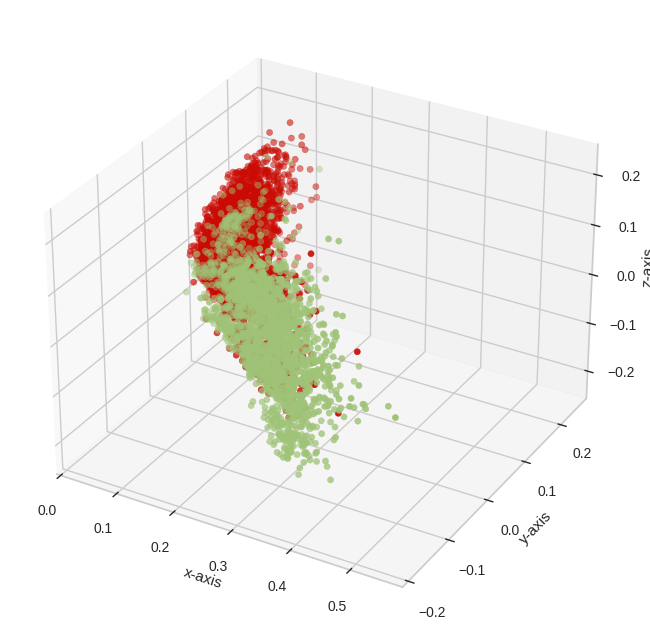

In [ ]:
# Importing library to visualize clusters in 3D
from mpl_toolkits.mplot3d import Axes3D

# Plot the clusters in 3D
fig = plt.figure(figsize=(20,8))
ax = fig.add_subplot(111, projection='3d')
colors = ['r', 'g', 'b', 'y']
for i in range(len(colors)):
    ax.scatter(x_transformed[Agmodel.labels_ == i, 0], x_transformed[Agmodel.labels_ == i, 1], x_transformed[Agmodel.labels_ == i, 2],c=colors[i])
ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-axis')
plt.show()

In [ ]:
# Add cluster values to the dateframe.
df_new['agglomerative_cluster'] = Agmodel.labels_

In [ ]:
df_new.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_detail,pos_tags,kmeans_cluster,agglomerative_cluster
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,Adult Content,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,jo miguel bianca comparato michel gomes rodolf...,"[(jo, NN), (miguel, NN), (bianca, NN), (compar...",2,0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,Adult Content,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,demi n bichir h ctor bonilla oscar serrano aza...,"[(demi, NN), (n, CC), (bichir, NN), (h, NN), (...",3,0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,Adult Content,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",tedd chan stella chung henley hii lawrence koh...,"[(tedd, NN), (chan, NN), (stella, NN), (chung,...",3,0
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,Teen Content,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",elijah wood john c reilly jennifer connelly ch...,"[(elijah, RB), (wood, NN), (john, NN), (c, VBP...",1,0
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,Teen Content,123 min,Dramas,A brilliant group of students become card-coun...,jim sturgess kevin spacey kate bosworth aaron ...,"[(jim, NN), (sturgess, NN), (kevin, NN), (spac...",1,0


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
def agglomerative_wordcloud(cluster_number, column_name):
  '''function for Building a wordcloud for the movie/shows'''

  #Importing libraries
  from wordcloud import WordCloud, STOPWORDS

  # Filter the data by the specified cluster number and column name
  df_wordcloud = df_new[['agglomerative_cluster', column_name]].dropna()
  df_wordcloud = df_wordcloud[df_wordcloud['agglomerative_cluster'] == cluster_number]

  # Combine all text documents into a single string
  text = " ".join(word for word in df_wordcloud[column_name])

  # Create the word cloud
  wordcloud = WordCloud(stopwords=set(STOPWORDS), background_color="black").generate(text)

  # Return the word cloud object
  return wordcloud

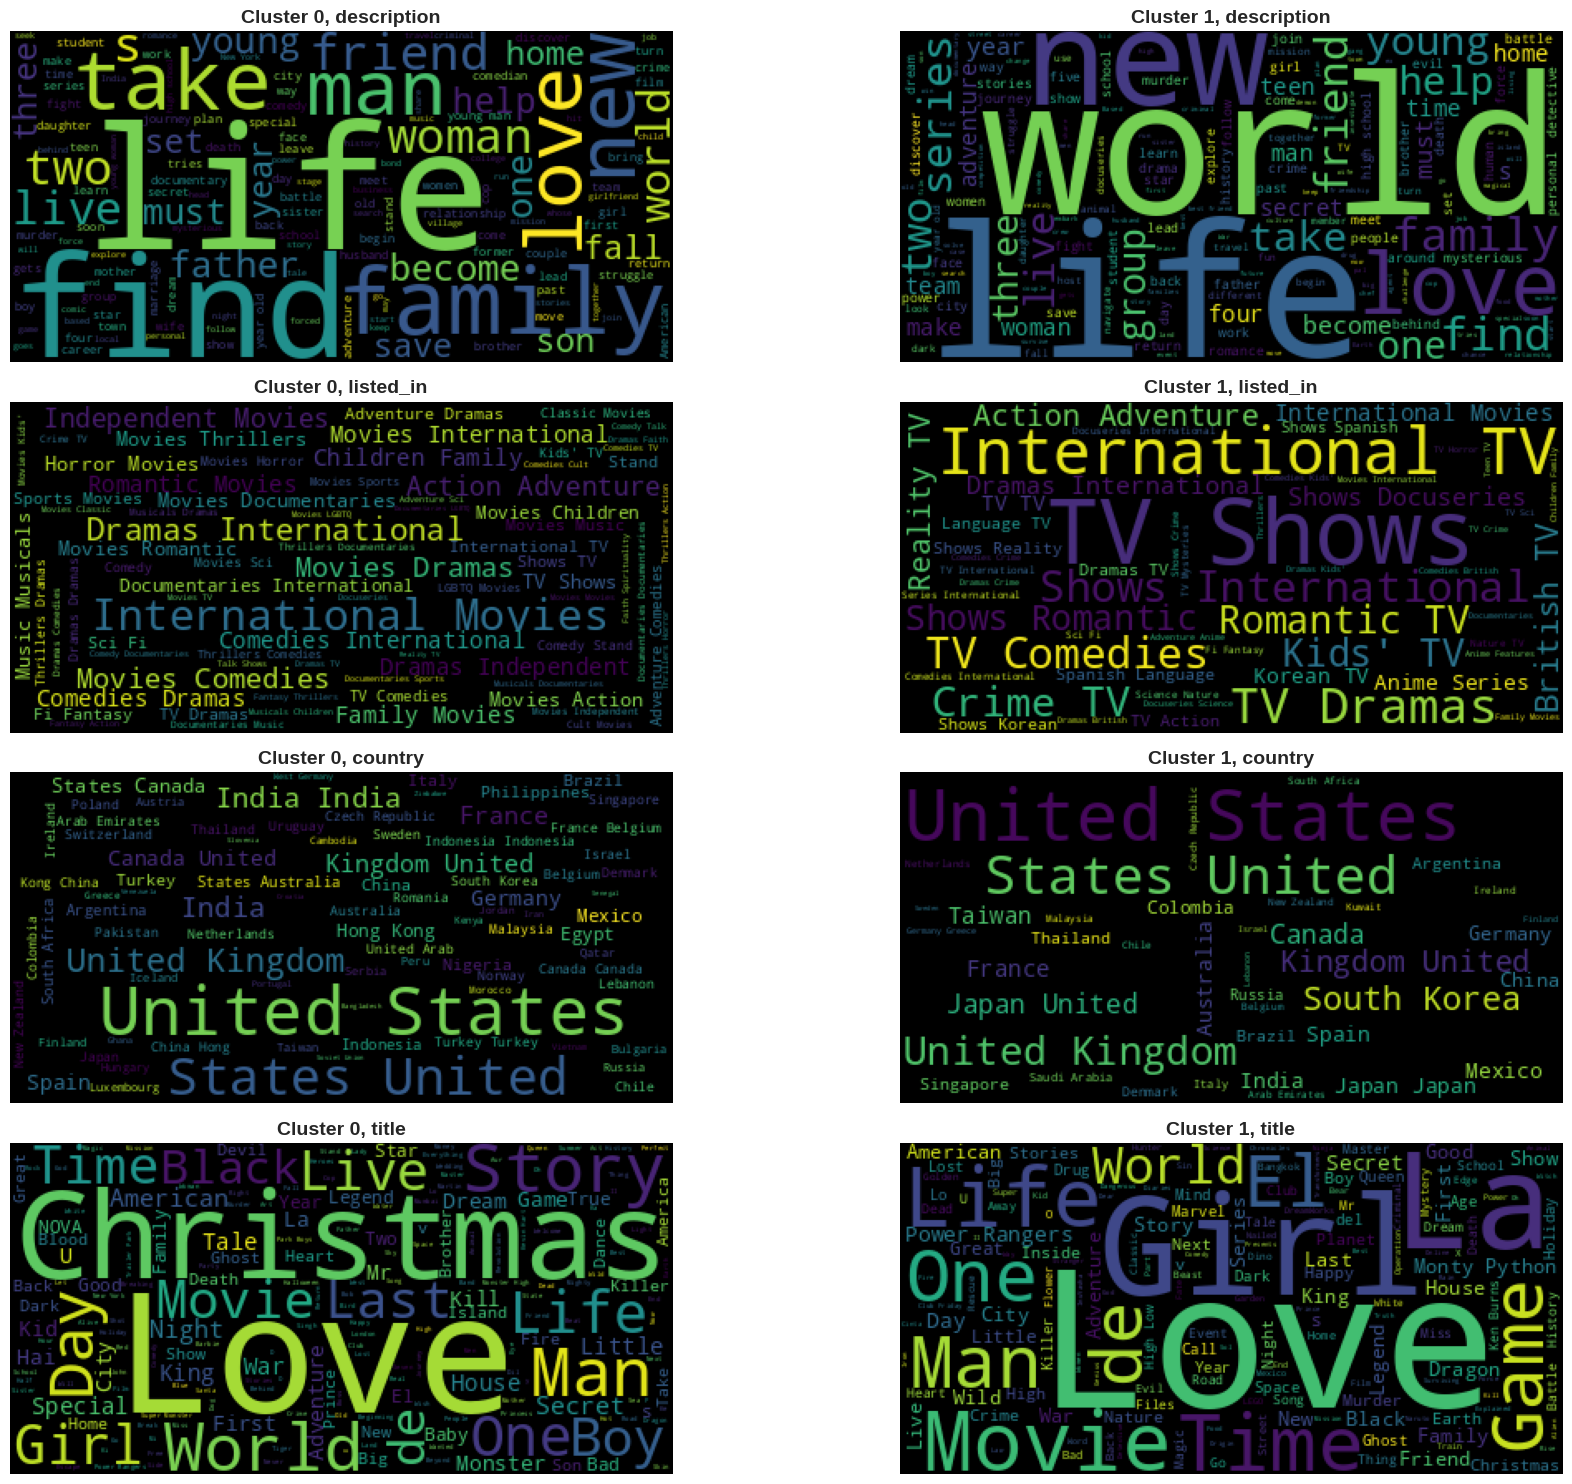

In [ ]:
# Implementing the above defined function and plotting the wordcloud of each attribute
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(20, 15))
for i in range(2):
    for j, col in enumerate(['description', 'listed_in', 'country', 'title']):
        axs[j][i].imshow(agglomerative_wordcloud(i, col))
        axs[j][i].axis('off')
        axs[j][i].set_title(f'Cluster {i}, {col}',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### ML Model - 3  (Building a Recommendation System)

We are using Cosine similarity as it is a measure of similarity between two non-zero vectors in a multidimensional space. It measures the cosine of the angle between the two vectors, which ranges from -1 (opposite direction) to 1 (same direction), with 0 indicating orthogonality (the vectors are perpendicular to each other).

In this project we have used cosine similarity which is used to determine how similar two documents or pieces of text are. We represent the documents as vectors in a high-dimensional space, where each dimension represents a word or term in the corpus. We can then calculate the cosine similarity between the vectors to determine how similar the documents are based on their word usage.

We'll are using cosine similarity over tf-idf because:

* Cosine similarity handles high dimensional sparse data better.

* Cosine similarity captures the meaning of the text better than tf-idf. For example, if two items contain similar words but in different orders, cosine similarity would still consider them similar, while tf-idf may not. This is because tf-idf only considers the frequency of words in a document and not their order or meaning.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Create a TF-IDF vectorizer object and transform the text data
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_new['content_detail'])

# Compute cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix)

def recommend_content(title, cosine_sim=cosine_sim, data=df_new):
    # Get the index of the input title in the programme_list
    programme_list = data['title'].to_list()
    index = programme_list.index(title)

    # Create a list of tuples containing the similarity score and index
    # between the input title and all other programmes in the dataset
    sim_scores = list(enumerate(cosine_sim[index]))

    # Sort the list of tuples by similarity score in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:11]

    # Get the recommended movie titles and their similarity scores
    recommend_index = [i[0] for i in sim_scores]
    rec_movie = data['title'].iloc[recommend_index]
    rec_score = [round(i[1], 4) for i in sim_scores]

    # Create a pandas DataFrame to display the recommendations
    rec_table = pd.DataFrame(list(zip(rec_movie, rec_score)), columns=['Recommendation', 'Similarity_score(0-1)'])

    return rec_table

In [ ]:
# Testing indian movie
recommend_content('Kuch Kuch Hota Hai')

,Recommendation,Similarity_score(0-1)
0,Kabhi Khushi Kabhie Gham,0.4353
1,Hello Brother,0.2702
2,Judwaa,0.2591
3,Kabhi Alvida Naa Kehna,0.2476
4,Kya Kehna,0.2240
5,Chalte Chalte,0.2087
6,Chaahat,0.2018
7,Paheli,0.1986
8,Hum Aapke Hain Koun,0.1961
9,Kal Ho Naa Ho,0.1842


In [ ]:
# Testing non indian movie
recommend_content('Hush')

,Recommendation,Similarity_score(0-1)
0,Before I Wake,0.1269
1,Trigger Warning with Killer Mike,0.1201
2,Killer Klowns from Outer Space,0.1151
3,Deaf U,0.1078
4,Oasis: Supersonic,0.0975
5,V for Vendetta,0.0975
6,Terrifier,0.0967
7,The Bye Bye Man,0.0962
8,Siren,0.0943
9,Swearnet Live,0.0931


In [ ]:
# Testing indian tv show
recommend_content('Khaani')

,Recommendation,Similarity_score(0-1)
0,Zindagi Kitni Haseen Hay,0.2577
1,Sadqay Tumhare,0.1833
2,Club Friday To Be Continued - My Beautiful Tomboy,0.1465
3,Wrong No.,0.1449
4,Teefa in Trouble,0.1418
5,Humsafar,0.1402
6,Pinky Memsaab,0.1374
7,Killer Ratings,0.1337
8,Janaan,0.1318
9,Tundukkan Playboy Itu,0.1307


In [ ]:
# Testing non indian tv show
recommend_content('Balto')

,Recommendation,Similarity_score(0-1)
0,Hook,0.1407
1,Dinotrux,0.1288
2,Balto 2: Wolf Quest,0.1198
3,Vampires,0.1149
4,Pick of the Litter,0.1062
5,Hold the Dark,0.0955
6,Jim Gaffigan: King Baby,0.0953
7,The Pirate Fairy,0.0936
8,To Be of Service,0.0859
9,Whitney Cummings: Can I Touch It?,0.0856


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

We have chosen **Silhoutte Score** over **Distortion Score (also known as inertia or sum of squared distances)** as evaluation metrics as it measures how well each data point in a cluster is separated from other clusters. It ranges from -1 to 1, with higher values indicating better cluster separation. A silhouette score close to 1 indicates that the data point is well-matched to its own cluster and poorly matched to neighboring clusters. A score close to 0 indicates that the data point is on or very close to the boundary between two clusters. A score close to -1 indicates that the data point is probably assigned to the wrong cluster.

The advantages of using silhouette score over distortion score are:

* Silhouette score takes into account both the cohesion (how well data points within a cluster are similar) and separation (how well data points in different clusters are dissimilar) of the clusters, whereas distortion score only considers the compactness of each cluster.
* **Silhouette score is less sensitive to the shape of the clusters**, while distortion score tends to favor spherical clusters, and in our case the clusters are not completely spherical.
* Silhouette score provides more intuitive and interpretable results, as it assigns a score to each data point rather than just a single value for the entire clustering solution.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

We have considered K-means as our final model, as we are getting the comparatevely high Silhoutte Score in K-means clustering and the resulted clusters are very well seperated from each others as have saw in the 3 dimensions.

# **Conclusion**

**Based on the exploratory data analysis (EDA), we can conclude the following**:

* Movies constitute the majority (72%) of Netflix's content, while TV shows make up the remaining portion (28%).
* Adult and Teen categories are the most prevalent in Netflix's content library.
* TV shows offer a larger selection of family-friendly content compared to movies.
* Raul Campos and Jan Suter are the most frequent directors of movies, while Alastair Fothergill and Ken Burns direct many TV shows.

**In terms of machine learning analysis, we can conclude the following:**

* K-Means Clustering suggests that the optimal number of clusters for the Netflix dataset is 4, while Agglomerative Hierarchical Clustering indicates 2 clusters.
* Silhouette Score was used as the evaluation metric, which provides a more intuitive and interpretable result.
* A recommendation system was built based on similarity scores to provide personalized recommendations to improve user experience and reduce subscriber churn.

**Additionally, we found the following insights:**

* The majority of movie actors on Netflix are from India, but popular Indian actors are not commonly found in TV shows.
* International movies/TV shows are the most popular genres, followed by Drama and Comedy.
* The United States and India have the highest number of content contributors on Netflix.
* The year 2019 saw the highest number of movie additions, while 2020 had the highest number of TV show additions, indicating significant growth and diversity in content during those years.
* Most movies on Netflix have a duration between 90 to 120 minutes.
* Adult content is produced in higher proportions by all countries except India. India produces a high percentage of Teen content. Canada leads in producing family-friendly content. Spain has the highest percentage (85%) of adult content.